# 🎓 TENURE PIPELINE: ACADEMIC FACULTY LONGITUDINAL DATASET

**Purpose**: Build a longitudinal panel of CS faculty at all 187 US R1 institutions to study how peer pool quality affects tenure (promotion from Assistant → Associate Professor).


**Research Design**: Replicate the inverted-U pattern seen in Army promotions and NBA draft rates — testing whether faculty in mid-tier departments have the highest tenure rates, while those in elite departments face signal compression and slot scarcity.

## Pipeline Structure

| Stage | Notebook Cell | Input | Output |
|-------|--------------|-------|--------|
| **1: DBLP Parse** | CELL 1 | `dblp.xml` (full dump) | `dblp_parsed/dblp_YYYY.jsonl` |
| **2: University List** | CELL 2 | `PILOT_SCHOOLS` in `r1_schools_data.py` | `r1_cs_departments.csv` |
| **3: Wayback** | CELL 3A–3B | R1 CS dept URLs | `faculty_snapshots_plan.jsonl` + HTML on disk |
| **4: Faculty parse** | CELL 4 | Archived HTML | `faculty_snapshots_parsed.jsonl` |
| **5: Panel build** | CELL 5 | Parsed rows + CDX plan join | `faculty_panel.jsonl` (incl. `snpsht_dt`) |

## Key Technical Features
- Streaming XML parse (`lxml.iterparse`) — memory-efficient for multi-GB DBLP dump
- Wayback Machine CDX API — programmatic access to 25 years of archived faculty pages
- `tqdm` progress bars + `time_start`/`time_stop` colorama feedback throughout
- Intermediate saves at each stage for checkpoint/resume

# 🧭 CELL 0 — Imports & path setup

Run this code cell first each session (`WORKSPACE_ROOT`, `TENURE_PIPELINE_DIR`, `sys.path`, `.env`, stage paths, `RUN_CELL*` flags). **`WORKSPACE_ROOT`** is the repo root (walks up to **`functionsG_working.py`**). **Pipeline data and `*.py`** live under **`tenure/tenure_pipeline/`** (`TENURE_PIPELINE_DIR`); a duplicate **`tenure_pipeline/`** at repo root is ignored for imports — see Cell 0 `sys.path` order.


In [8]:
# === CELL 0: IMPORTS & PATH SETUP ===
# Imports all necessary libraries and configures paths for the tenure pipeline.
# All stage constants (years, tags, output dirs) are defined here for easy modification.


# Matplotlib: use inline backend first (same idea as 520 + talent_pipeline/cox_plot_helpers.py).
# Then savefig + plt.show() + plt.close(fig) in tenure_pipeline/viz_pipeline.py shows in the notebook
# and saves to disk without blocking interactive GUI backends.
%matplotlib inline

# === 0.1. STANDARD LIBRARY ===
import sys, os, json, time, tempfile, re
from datetime import datetime
from pathlib import Path

# === 0.2. PATH SETUP ===
# Kernel cwd is often tenure/ when this notebook lives under tenure/ — walk up to repo root.
def _find_workspace_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "functionsG_working.py").is_file():
            return p
    return here

WORKSPACE_ROOT = _find_workspace_root()
# Canonical on-disk pipeline package (same tree as ``tenure/tenure_pipeline/*.py``; matches .gitignore paths).
TENURE_PIPELINE_DIR = WORKSPACE_ROOT / "tenure" / "tenure_pipeline"
# Logical prefix for ``local_path`` in plan/index JSONL (new rows). Legacy ``tenure_pipeline/faculty_snapshots/…`` still read.
SNAPSHOT_LOCAL_PREFIX = "tenure/tenure_pipeline/faculty_snapshots"

# Import order matters: a duplicate ``tenure_pipeline/`` exists at repo root; prefer ``tenure/tenure_pipeline/``.
sys.path.insert(0, str(WORKSPACE_ROOT))
sys.path.insert(0, str(TENURE_PIPELINE_DIR))
sys.path.insert(0, str(WORKSPACE_ROOT / "tenure"))

# === 0.2b. Repo-root `.env` (gitignored: OPENALEX_API_KEY, OPENALEX_MAILTO, HTTP_CONTACT_EMAIL) ===
try:
    from dotenv import load_dotenv
    load_dotenv(WORKSPACE_ROOT / ".env")
except ImportError:
    pass  # pip install python-dotenv  OR  export vars in shell before Jupyter

# === 0.3. SHARED UTILITY FUNCTIONS ===
from functionsG_working import time_start, time_stop, hms_string, tymeout, tyme, store_json, load_json, load_feather, store_feather

# === 0.4. DATA & PARSING ===
import requests
from lxml import etree
from tqdm.auto import tqdm
import pandas as pd
import numpy as np

# === 0.5. STAGE 1 CONSTANTS: DBLP PARSE ===
DBLP_XML      = WORKSPACE_ROOT / 'python_packages' / 'dblp-parser' / 'dblp.xml'
DBLP_DTD      = WORKSPACE_ROOT / 'python_packages' / 'dblp-parser' / 'dblp.dtd'
STAGE1_OUT_DIR = TENURE_PIPELINE_DIR / 'dblp_parsed'
TARGET_TAGS   = ['article', 'inproceedings']

# === 0.6. STAGE 2 CONSTANTS: UNIVERSITY LIST ===
STAGE2_OUT      = TENURE_PIPELINE_DIR / 'r1_cs_departments.csv'

# === 0.7. STAGE 3 CONSTANTS: WAYBACK CDX SCRAPE ===
STAGE3_PLAN          = TENURE_PIPELINE_DIR / 'faculty_snapshots_plan.jsonl'
STAGE3_RETRY         = TENURE_PIPELINE_DIR / 'cdx_retry_queue.jsonl'
STAGE3_INDEX         = TENURE_PIPELINE_DIR / 'faculty_snapshots_index.jsonl'
# Raw HTML tree. Plan/index JSONL use logical paths under ``tenure/tenure_pipeline/faculty_snapshots/…`` (new); legacy ``tenure_pipeline/faculty_snapshots/…`` still resolved; see resolve_faculty_snapshot_path().
# "temp" = OS temp dir (macOS: /var/folders/.../T/...) — avoids Dropbox and iCloud Desktop & Documents (0 B stat/read-back).
# "desktop" = ~/Desktop/faculty_snapshots | "workspace" = repo tree under tenure/tenure_pipeline/faculty_snapshots
FACULTY_SNAPSHOTS_STORAGE = "workspace"  # "temp" = reliable writes (see NOTE). "desktop" often breaks verify with iCloud Desktop.
if FACULTY_SNAPSHOTS_STORAGE == "temp":
    STAGE3_HTML_DIR = Path(tempfile.gettempdir()) / "faculty_snapshots_html"
elif FACULTY_SNAPSHOTS_STORAGE == "desktop":
    STAGE3_HTML_DIR = Path.home() / "Desktop" / "faculty_snapshots"
else:
    STAGE3_HTML_DIR = TENURE_PIPELINE_DIR / "faculty_snapshots"
# STAGE3_HTML_DIR = Path("/tmp/faculty_snapshots_html")  # optional hard override (uncomment; wins over FACULTY_SNAPSHOTS_STORAGE)
# Cell 3B download writes ALWAYS use FACULTY_SNAPSHOTS_WRITE_ROOT (separate from STAGE3_HTML_DIR / search roots).
# WRITE_ROOT_MODE: "desktop" = ~/Desktop/faculty_snapshots | "workspace" = repo …/faculty_snapshots | "temp" = $TMPDIR tree
# (sandboxed Jupyter often EPERMs large writes under $TMPDIR; Desktop/workspace avoid that.)
FACULTY_SNAPSHOTS_WRITE_ROOT_MODE = "workspace"  # "workspace" (default) | "desktop" | "temp" — desktop often EPERM under sandbox/iCloud
if FACULTY_SNAPSHOTS_WRITE_ROOT_MODE == "workspace":
    FACULTY_SNAPSHOTS_WRITE_ROOT = TENURE_PIPELINE_DIR / "faculty_snapshots"
elif FACULTY_SNAPSHOTS_WRITE_ROOT_MODE == "desktop":
    FACULTY_SNAPSHOTS_WRITE_ROOT = Path.home() / "Desktop" / "faculty_snapshots"
else:
    FACULTY_SNAPSHOTS_WRITE_ROOT = Path(tempfile.gettempdir()) / "faculty_snapshots_html"
STAGE3C_TARGETS      = TENURE_PIPELINE_DIR / 'faculty_subpage_targets.json'
STAGE3C_INDEX        = TENURE_PIPELINE_DIR / 'faculty_subpage_index.jsonl'
STAGE3D_TARGETS      = TENURE_PIPELINE_DIR / 'faculty_subpage_d_targets.json'
STAGE3D_INDEX        = TENURE_PIPELINE_DIR / 'faculty_subpage_d_index.jsonl'
STAGE3E_INDEX        = TENURE_PIPELINE_DIR / 'faculty_subpage_e_index.jsonl'
# Total UG+grad enrollment by year (IPEDS/NCES-style); university must match STAGE2_OUT exactly.
STAGE3_ENROLLMENT    = TENURE_PIPELINE_DIR / 'school_enrollment_annual.csv'

# === 0.7b. STAGE 4 CONSTANTS: HTML FACULTY PARSE ===
STAGE4_OUT           = TENURE_PIPELINE_DIR / 'faculty_snapshots_parsed.jsonl'
STAGE4_STRAT_OUT     = TENURE_PIPELINE_DIR / 'faculty_snapshots_strategy_audit.jsonl'

# === 0.7c. STAGE 5 CONSTANTS: LONGITUDINAL PANEL ===
STAGE5_OUT           = TENURE_PIPELINE_DIR / 'faculty_panel.jsonl'
STAGE5_COLLISIONS    = TENURE_PIPELINE_DIR / 'faculty_panel_collisions.jsonl'

# === 0.7d. STAGE 6 CONSTANTS: OPENALEX AUTHOR RESOLUTION + WORKS ===
# OpenAlex: set OPENALEX_API_KEY and OPENALEX_MAILTO in repo-root `.env` (loaded above; see .env.example).
STAGE6_INST_MAP      = TENURE_PIPELINE_DIR / 'openalex_inst_map.json'
STAGE6_AUTHOR_IDS    = TENURE_PIPELINE_DIR / 'openalex_author_ids.jsonl'
STAGE6_WORKS         = TENURE_PIPELINE_DIR / 'openalex_works_by_year.jsonl'
STAGE6_WORKS_CACHE   = TENURE_PIPELINE_DIR / 'openalex_snapshot_cache.jsonl'  # incremental cache — never re-scan a cached author
STAGE6B_API_FALLBACK = False  # True = use OpenAlex API for authors not in cache (slow/rate-limited)
STAGE6_LOW_CONF      = TENURE_PIPELINE_DIR / 'openalex_low_confidence.jsonl'

# === 0.7e. STAGE 7 CONSTANTS: ENRICHED ANNUAL PANEL ===
STAGE7_OUT           = TENURE_PIPELINE_DIR / 'faculty_panel_enriched.jsonl'
STAGE7_GAP_TOLERANCE = 4   # max years between last asst obs and a promotion event

# === 0.7f. STAGE 8 CONSTANTS: POOL METRICS ===
STAGE8_OUT           = TENURE_PIPELINE_DIR / 'faculty_panel_with_pools.jsonl'

# === 0.7g. STAGE 9 CONSTANTS: INVERTED-U ANALYSIS ===
STAGE9_N_BINS     = 18           # number of bins (default 12)
STAGE9_FIG        = TENURE_PIPELINE_DIR / 'stage9_inverted_u.png'
STAGE9_TABLE      = TENURE_PIPELINE_DIR / 'stage9_binned_table.csv'
STAGE9_BIN_METHOD = 'quantile'  # 'quantile' (equal N) or 'equal_width'
STAGE9_LOG_BIN    = False        # if True, bin on log(1+LOO) — best with equal_width
STAGE9_Z_SCORE    = False         # if True, z-score the (log) LOO before binning

# Stage 6B: optional CDH bulk snapshot (Rivanna: ~/cdh/OpenAlex1125). If this tree
# contains publicationauthoraffiliation/ and pub2year.csv.gz, Cell 6B uses CSV scans
# instead of the OpenAlex API. Override with env OPENALEX_SNAPSHOT_ROOT.
_oas = (os.environ.get("OPENALEX_SNAPSHOT_ROOT") or "").strip()
OPENALEX_SNAPSHOT_ROOT = Path(_oas).expanduser() if _oas else (Path.home() / "cdh" / "OpenAlex1125")


def _faculty_snapshot_rel_from_local_path(local_path: str):
    """Path under faculty_snapshots/... relative to each root, or None if not a standard plan local_path."""
    lp = (local_path or "").replace("\\", "/").strip()
    _new = SNAPSHOT_LOCAL_PREFIX + "/"
    _legacy = "tenure_pipeline/faculty_snapshots/"
    if lp.startswith(_new):
        return lp[len(_new) :].lstrip("/")
    if lp.startswith(_legacy):
        return lp[len(_legacy) :].lstrip("/")
    return None


def faculty_snapshot_search_roots():
    """Roots to search for existing HTML (3B skip, Cell 4 parse). Deduped; 3B write root first, then STAGE3_HTML_DIR, …"""
    roots = []
    seen = set()
    for d in (
        FACULTY_SNAPSHOTS_WRITE_ROOT,
        STAGE3_HTML_DIR,
        TENURE_PIPELINE_DIR / "faculty_snapshots",
        WORKSPACE_ROOT / "tenure_pipeline" / "faculty_snapshots",
        Path.home() / "Desktop" / "faculty_snapshots",
    ):
        try:
            r = d.resolve()
        except OSError:
            continue
        if r not in seen:
            seen.add(r)
            roots.append(r)
    return roots


def resolve_faculty_snapshot_path(local_path: str, *, for_write: bool = False) -> Path:
    """Map plan local_path to disk. for_write=True → FACULTY_SNAPSHOTS_WRITE_ROOT (3B saves). Else first existing file among search roots, else STAGE3_HTML_DIR primary (missing)."""
    lp = (local_path or "").replace("\\", "/").strip()
    rel = _faculty_snapshot_rel_from_local_path(lp)
    if rel is None:
        return (WORKSPACE_ROOT / lp).resolve()
    primary = (STAGE3_HTML_DIR / rel).resolve()
    if for_write:
        return (FACULTY_SNAPSHOTS_WRITE_ROOT / rel).resolve()
    for root in faculty_snapshot_search_roots():
        p = (root / rel).resolve()
        if p.is_file():
            return p
    return primary


def disk_html_to_plan_local_path(html_path: Path) -> str:
    """Inverse: HTML file on disk -> canonical local_path string for parsed JSONL (matches plan)."""
    html_path = html_path.resolve()
    for root in faculty_snapshot_search_roots():
        try:
            rel = html_path.relative_to(root)
            return f"{SNAPSHOT_LOCAL_PREFIX}/{rel.as_posix()}"
        except ValueError:
            continue
    return html_path.relative_to(WORKSPACE_ROOT).as_posix()


CDX_YEAR_MIN    = 2000
CDX_YEAR_MAX    = 2024
CDX_SEASONS     = {'spring': '0315', 'fall': '1015'}  # anchor dates for ranking captures within each year
# Multi-capture: up to CDX_SNAPS_PER_SEASON distinct timestamps per (year, season).  If more CDX rows exist,
# keep the closest (CDX_SPACING_POOL_MULT × cap) to the anchor, sort by time, then subsample for even spacing.
CDX_SNAPS_PER_SEASON   = 12
CDX_SPACING_POOL_MULT  = 2   # inner pool size = min(len(candidates), mult × CDX_SNAPS_PER_SEASON) before spacing
CDX_SLEEP_BEFORE_RETRY_SEC = 30 * 60   # bridge cell after 3A-VIZ: pause before 3A-RETRY (Archive cool-down)
CDX_DELAY           = 2.0   # seconds between requests — pass 1 (60/min IA limit)
CDX_TIMEOUT         = 45    # CDX API (not the calendar UI) — often 15–40s+ under load; 20s caused false timeouts
CDX_RETRY_TIMEOUT   = 60    # overnight Cell 3A-RETRY — stubborn URLs after pass-1 timeout
CDX_HTML_TIMEOUT    = 45    # seconds before an HTML download is abandoned (pages can be large)
CDX_DEFERRED_WAIT   = 90    # seconds to pause before retrying deferred/connection-error URLs
CDX_DEFERRED_DELAY  = 3.0   # seconds between requests — pass 2 (slower, gentler)
_http_contact = (os.environ.get("HTTP_CONTACT_EMAIL") or "").strip()
CDX_HEADERS     = {
    'User-Agent': (
        'TenurePipelineResearch/1.0 '
        '(Academic research; University of Virginia'
        + (_http_contact and f'; contact: {_http_contact}' or '')
        + ')'
    )
}

# === 0.8. EXECUTION FLAGS ===
# Set True to run each heavy cell; False to skip (function definitions still load)
# When False, each cell loads its output from disk so downstream cells still work.
RUN_CELL1          = True  # DBLP streaming parse           — ~30–45 min on full XML
RUN_CELL2          = True  # University list → CSV          — complete (114 schools)
RUN_CELL3_CDX      = True  # Wayback CDX discovery — uses CDX_TIMEOUT (see above) [OFF: quota guard]
RUN_CELL3_COOLDOWN = False  # CDX cool-down — sleeps for CDX_SLEEP_BEFORE_RETRY_SEC before the retry
RUN_CELL3_RETRY    = False  # CDX retry pass — uses CDX_RETRY_TIMEOUT (see above)
RUN_CELL3_DOWNLOAD = True  # Wayback HTML download          — all newly discovered files
RUN_CELL3C         = False  # Cornell/UMD sub-page rescue    — complete
RUN_CELL3D         = False  # UIUC/UW-Madison sub-page rescue — complete
RUN_CELL3E         = True  # NC State redirect rescue       — retry (failed conn errors @ 11pm)
RUN_CELL4          = True  # HTML faculty parse             — ~2 min across 56 good schools
# Daily wave: limit 3A / 3B / 4 to these uni_slug values; None = all schools
WAYBACK_SLUGS = None  # e.g. ["arizona_state_university"] or CLI: run_wayback_wave.py --slugs ...
RUN_WAVE_REPORT_AFTER_PARSE = True  # after Cell 4: plan | HTML | avg recs (wayback_wave_report.py)
RUN_CELL5          = True  # Longitudinal panel builder     — ~5 sec
RUN_CELL6A         = True   # OpenAlex institution map + author ID resolution — ~10 min (network)
RUN_CELL6B         = True   # OpenAlex works by year — snapshot mode (cache builder done)
RUN_CELL7          = True  # Enriched annual panel — ~30–60 sec (in-memory; 895 MB panel JSONL)
RUN_CELL8          = True  # LOO peer pool metrics — two-pass over 106K-row enriched panel
RUN_CELL9          = True  # Inverted-U analysis — ~5 sec

# --- Stage 6A pilot (order + optional subset): high panel coverage first; sanity filter from Cell 4 audit ---
STAGE6_PILOT_MODE = True               # False = legacy alphabetical school order
STAGE6_PILOT_TOP_N = 40                # only top-N schools by coverage (pilot); None = all (still ranked)
STAGE6_SANITY_FILTER = True            # use STAGE4_STRAT_OUT (winner == 'none' rate)
STAGE6_SANITY_MAX_NONE_FRAC = 0.35    # drop school if frac_none (fraction of schools whose winner was 'none')> this (needs enough audit rows)
STAGE6_SANITY_MIN_AUDIT_ROWS = 3      # min audit rows per school to apply the rule


# === 0.8.1. UTILITY: HOT-RELOAD PIPELINE MODULES ===
def reload_py_files(verbose=True):
    """
    Reload all custom .py modules so in-place edits take effect without
    restarting the kernel.  Call at the top of any cell that uses
    html_parser, viz_pipeline, faculty_linker, or r1_schools_data.
    """
    import importlib
    _tp = str(TENURE_PIPELINE_DIR)
    if _tp not in sys.path:
        sys.path.insert(0, _tp)
    _modules = ['html_parser', 'viz_pipeline', 'faculty_linker', 'r1_schools_data', 'panel_builder', 'pool_metrics', 'stage9_analysis']
    reloaded = []
    for mod_name in _modules:
        try:
            if mod_name in sys.modules:
                importlib.reload(sys.modules[mod_name])
            else:
                importlib.import_module(mod_name)
            reloaded.append(mod_name)
        except Exception as e:
            print(f'  ⚠  reload_py_files: {mod_name}.py — {e}')
    if verbose and reloaded:
        print(f'  ↺  reload_py_files: {", ".join(r + ".py" for r in reloaded)}')


def run_wayback_url_report(slugs=None):
    """Post-wave table: plan snaps | HTML on disk | mean parse recs. Uses WAYBACK_SLUGS when slugs is None."""
    from wayback_wave_report import print_wave_report
    _sl = slugs if slugs is not None else (set(WAYBACK_SLUGS) if WAYBACK_SLUGS else None)
    print_wave_report(tenure_pipeline_dir=TENURE_PIPELINE_DIR, wayback_slugs=_sl)

# === 0.9. SUMMARY ===
print(f"  Workspace root   : {WORKSPACE_ROOT}")
if DBLP_XML.exists():
    print(f"  DBLP XML         : {DBLP_XML}  ({DBLP_XML.stat().st_size / 1e9:.2f} GB)")
else:
    print(f"  DBLP XML         : {DBLP_XML}  (not found — add dump or ignore if not running Stage 1)")
print(f"  Stage 1 out dir  : {STAGE1_OUT_DIR.resolve()}")
print(f"  STAGE3_HTML_DIR  : {STAGE3_HTML_DIR}  (FACULTY_SNAPSHOTS_STORAGE={FACULTY_SNAPSHOTS_STORAGE!r})")
print(f"  3B write root      : {FACULTY_SNAPSHOTS_WRITE_ROOT}  (WRITE_ROOT_MODE={FACULTY_SNAPSHOTS_WRITE_ROOT_MODE!r})")
print("  NOTE: Skip/resume + Cell 4 search: 3B write root, STAGE3_HTML_DIR, workspace …/faculty_snapshots, ~/Desktop/faculty_snapshots.")
print(f"  Target types     : {TARGET_TAGS}")
_paa = OPENALEX_SNAPSHOT_ROOT / "publicationauthoraffiliation"
_p2y = OPENALEX_SNAPSHOT_ROOT / "pub2year.csv.gz"
if _paa.is_dir() and _p2y.is_file():
    print(f"  OpenAlex 6B       : snapshot OK → {OPENALEX_SNAPSHOT_ROOT} (CSV mode, no API)")
else:
    print(f"  OpenAlex 6B       : {OPENALEX_SNAPSHOT_ROOT}  (missing PAA or pub2year — 6B uses API)")
print(f"\n  Ready. {tymeout()}")

  Workspace root   : /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE
  DBLP XML         : /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/python_packages/dblp-parser/dblp.xml  (5.10 GB)
  Stage 1 out dir  : /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/tenure/tenure_pipeline/dblp_parsed
  STAGE3_HTML_DIR  : /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/tenure/tenure_pipeline/faculty_snapshots  (FACULTY_SNAPSHOTS_STORAGE='workspace')
  3B write root      : /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Curs

In [9]:
##### EDIT BLANK ###### DISCARD
# session: 2026-10-02 18:26 — Cell 0 RUN_WAVE_REPORT_AFTER_PARSE + run_wayback_url_report()
# session: 2026-10-02 — stage3b_download.py (staging + permanent-fail skip)
# session: 2026-05-13 — Slurm stdout/stderr → Ivy_Net/slurm_out/
# session: 2026-04-15 — Phase 3: PILOT_TOP_N=40, RUN_CELL6A=True, RUN_CELL6B=True
# session: 2026-04-15 — fix indent on RUN_CELL3_CDX and RUN_CELL6B lines
# session: 2026-04-15 — RUN_CELL3_CDX=False, RUN_CELL6B=False (safe overnight: cache builder runs separately)
# session: 2026-04-18 — Cell 5: rank breakdown + per-step timing; donut viz fix (legend replaces slice labels)
# session: 2026-04-16 — openalex_snapshot_cache: incremental cache for Cell 6B snapshot scan; STAGE6_WORKS_CACHE constant; cache_path wired into fetch_works_by_year
# session: 2026-04-15 — Cell 9: log_bin param + STAGE9_LOG_BIN constant; equal_width/log_bin smoke-test; yerr clamp fix
# session: 2026-04-15 — Cell 9: 12 bins, bin_method, z_score params; apply_url_updates.sh wrapper; apply_url_updates.py Python 3.6 fixes
# session: 2026-04-15 — Cell 9: stage9_analysis.py + STAGE9 constants + RUN_CELL9; inverted-U plot (tenure/attrition rate vs LOO decile)
# session: 2026-04-15 — Cells 7+8: panel_builder.py + pool_metrics.py; STAGE7/8 constants + RUN flags; Cell 7 enriched panel + Cell 8 LOO peer pool metrics
# session: 2026-04-14 — Cell 0: TENURE_PIPELINE_DIR = tenure/tenure_pipeline (align w/ repo + .gitignore)
# session: 2026-04-14 — STAGE6_PILOT_TOP_N=15; TENURE_PIPELINE_OVERVIEW §6A pilot bullets
# session: 2026-04-14 — Stage 6A pilot: coverage rank + STAGE4 strat sanity (stage6_pilot.py)
# session: 2026-04-14 — WORKSPACE_ROOT: walk up to repo root (functionsG_working.py) when cwd is tenure/
# session: 2026-04-14 — CELL 0 header emoji (🧭) to match other stage headers
# session: 2026-04-14 — CELL 0 outline markdown placed before CELL 0 code (outline / reorder)
# session: 2026-04-07 — CELL 50: Author ID Scratchpad (pd.read_json lines=True for jsonl)
# session: 2026-04-12 — CELL 3B: staging tmp unlink AFTER dest verify; TMPDIR print + SAVED → path
# session: 2026-04-12 — CELL 3B: ASU large HTML temp staging + install (wrapped write loop)
# session: 2026-04-12 — CELL 3B: large HTML → temp staging + cp into Dropbox (ASU disappear fix)
# session: 2026-04-12 — CELL 3B: read-back verify openssl/shasum/stat when cat+kernel fail (sandbox)
# session: 2026-04-12 — CELL 0: sys.path += tenure_pipeline (flat imports: apply_url_updates, …)
# session: 2026-04-12 — 3B: EPERM shell bypass (kernel sandbox vs Dropbox write_bytes)
# session: 2026-04-07 — CELL 0: WRITE_ROOT_MODE default workspace; 3B EPERM fallback to workspace
# session: 2026-04-07 — CELL 0: FACULTY_SNAPSHOTS_WRITE_ROOT_MODE desktop (~/Desktop/faculty_snapshots for 3B)
# session: 2026-04-07 — CELL 0: FACULTY_SNAPSHOTS_WRITE_TO_WORKSPACE (sandbox EPERM on large writes to $TMPDIR)
# session: 2026-04-07 — markdown: CELL 3B header cell before 3B code
# session: 2026-04-07 — CELL 0: WRITE_ROOT = gettempdir (not /tmp — sandboxed Jupyter gets EPERM on /private/tmp)
# session: 2026-04-07 — CELL 3B: _wp.resolve + write_bytes/fsync/read_bytes (single path for write+verify)
# session: 2026-04-07 — CELL 3B: write via os.open+fsync; WRITE_ROOT=/tmp (avoid TMPDIR + replace races)
# session: 2026-04-07 — CELL 0: FACULTY_SNAPSHOTS_WRITE_ROOT (3B always temp; STAGE3_HTML_DIR = search/viz only)
# session: 2026-04-07 — CELL 0: multi-root faculty_snapshot search (temp write + workspace/Desktop skip)
# session: 2026-04-07 — 3B: temp storage default + Wayback id_ retry on empty body; verify hint for missing file
# session: 2026-04-07 — CELL 0: FACULTY_SNAPSHOTS_STORAGE = desktop (per user)
# session: 2026-04-07 — CELL 0: FACULTY_SNAPSHOTS_STORAGE default temp (fixes iCloud Desktop 0 B read-back)
# session: 2026-04-12 — CELL 3B: atomic write + read-back verify (iCloud/Desktop stat can stay 0 B)
# session: 2026-04-12 — CELL 0: STAGE3_HTML_DIR → ~/Desktop/faculty_snapshots + path helpers
# session: 2026-04-12 — CELL 0: USE_DESKTOP_FACULTY_SNAPSHOTS + resolve_faculty_snapshot_path / disk_html_to_plan_local_path
# session: 2026-04-12 — CELL 3B: post-write fsync + stat retries (Dropbox); avoid premature unlink on verify
# session: 2026-04-12 — CELL 3B: ghost-index warning (Dropbox/cloud placeholders) + resolved path checks
# session: 2026-04-12 — CELL 3B dedupe local_path; CELL 6B safe summary + RUN_CELL6B hint
# session: 2026-04-07 — plot_stage3a_enrollment_bin_heatmap (quantile + equal_width; 540 CELL 3A-VIZ)
# session: 2026-04-07 — enrollment viz wired (STAGE3_ENROLLMENT + plot_stage3a/b)
# session: 2026-04-11 — CELL 3A→3A-RETRY bridge: hourglass + CDX_SLEEP_BEFORE_RETRY_SEC
# session: 2026-04-07 — CDX up to 12/sn band + temporal spacing; sniff_wayback_ts_from_html (legacy filenames)
# session: 2026-04-10 — CELL 3A/3B: multi-capture per season (CDX_SNAPS_PER_SEASON); ts filenames; panel dedupe by local_path
# session: 2026-04-10 — CELL 5: print plan-join counts (path / basename / missing)
# session: 2026-04-10 — viz_pipeline: savefig + show + close (cox_plot_helpers pattern); CELL 0 %matplotlib inline
# session: 2026-04-10 — Cell 5: Wayback plan join → snpsht_dt, local_path on panel; basename fallback for legacy HTML paths
# session: 2026-04-09 — Cell 4-VIZ: plot_stage4_diag prefers parsed_path; clarify avg/snapshot vs avg/file
# session: 2026-04-09 — plan_row_type cdx_bookmark (replace n_snaps=-1 bookmarks in plan JSONL)
# session: 2026-04-09 — Cell 3B: ignore CDX bookmark rows (n_snaps=-1, no reason) for plan block
# session: 2026-04-09 — Cell 4: CELL4_CONDEMN_ON_FAILURE default False (no plan sentinel / no HTML delete)
# session: 2026-04-09 — Cell 4: CELL4_PARSE_DESPITE_PLAN_SENTINEL override for post-parser retry
# session: 2026-04-09 — Cell 3B: honor n_snaps=-1 plan sentinels (scan raw plan before strip)
# session: 2026-04-09 — Cell 4: skip parse when plan last says Cell 4 condemned (unless CDX superseded)
# session: 2026-04-07 — Cell 3B: comment block — index vs disk for skip/resume
# session: 2026-04-07 — Cell 3B: skip on disk only; write verify; ghost-index warning
# session: 2026-04-07 — CDX_TIMEOUT increase to 20s
# session: Apr 7 2026 — re-apply Cell 3A fixes via EditNotebook
# session: 2026-04-08 — fix URL trailing-slash mismatch in tried_urls
# session: 2026-04-08 — write queried-URL bookmark for successful CDX results
# session: 2026-04-08 — CDX_TIMEOUT 45s (CDX API slower than Wayback calendar UI)
# session: 2026-04-08 — Option B: per-source_url snapshot paths (faculty_source_id)
# session: 2026-04-08 — legacy/ + rglob in 3D/3E; iter_school_html_files() in apply_url_updates
# session: 2026-04-08 — plot_stage4_diag rank_dist_logx optional
# session: 2026-04-08 — viz school_sort volume vs alphabetical (3A–5)
from functionsG_working import tyme
print(f"Edit BLANK: {tyme()}")  # burn slot

Edit BLANK: 10/02/2026 19:25:12


# 📚 CELL 1: STAGE 1 — DBLP STREAMING PARSE

##### **Input**: `python_packages/dblp-parser/dblp.xml` (full DBLP dump, ~5 GB)
##### **Output**: `tenure_pipeline/dblp_parsed/dblp_YYYY.jsonl` — one file per year
##### **Focus**: Checkpoint/resume parse with per-year output and flexible overwrite control

**Checkpoint / resume logic:**
- At startup, checks which years in `[year_min, year_max]` already have non-empty `.jsonl` files
- Skips those years automatically — safe to re-run at any time
- `overwrite=None` → skip all done years
- `overwrite=True` → re-parse all years in range
- `overwrite=[2015, 2016]` → re-parse only those specific years

**Fields extracted per record**:

| Field | Type | Description |
|-------|------|-------------|
| `type` | str | `article` or `inproceedings` |
| `key` | str | DBLP unique key (e.g. `conf/nips/LeCunBH89`) |
| `year` | str | Publication year |
| `authors` | list | Author name strings (DBLP-disambiguated) |
| `venue` | str | Booktitle (conferences) or journal name |
| `title` | str | Full paper title (HTML sub-tags stripped via `itertext()`) |

In [5]:
# === CELL 1: STAGE 1 — DBLP STREAMING PARSE ===
# Streams the DBLP XML dump using lxml iterparse — memory-efficient, never loads full tree.
# Writes one JSONL file per year into STAGE1_OUT_DIR (tenure_pipeline/dblp_parsed/).
# Skips years with existing non-empty output files (checkpoint/resume).
# overwrite=None/False → skip done years | overwrite=True → redo all | overwrite=[2015] → redo specific years
# ETA: seeded from parse_timing.json (historical rates); falls back to file-size estimate on first run.

_FALLBACK_BPR = 620   # fallback: estimated bytes per XML record (used only when no timing log exists)
_ETA_SECS     = 5    # seconds between ETA recalculation in the progress bar


def _load_timing_log(log_path):
    """Load parse_timing.json → dict keyed by run_id, or {} if absent/corrupt."""
    if Path(log_path).exists():
        try:
            with open(log_path) as f:
                return json.load(f)
        except Exception:
            pass
    return {}


def _save_timing_log(log_path, new_entry):
    """Append/update parse_timing.json with a new timing entry keyed by run_id."""
    log = _load_timing_log(log_path)
    log[new_entry['run_id']] = new_entry
    Path(log_path).parent.mkdir(parents=True, exist_ok=True)
    with open(log_path, 'w') as f:
        json.dump(log, f, indent=2)


def stream_dblp(xml_path, out_dir, year_min, year_max, overwrite=None, verbose=True):
    """
    Stream the DBLP XML dump and write filtered records to per-year JSONL files.

    Parameters
    ----------
    xml_path  : Path        path to dblp.xml
    out_dir   : Path        directory for per-year output files (created if absent)
    year_min  : int         first year to include (inclusive)
    year_max  : int         last year to include (inclusive)
    overwrite : None|bool|list  None/False → skip years with existing files
                                True       → overwrite all years in range
                                [2015,2016]→ overwrite only those years
    verbose   : bool        print per-year summary table on completion

    Returns
    -------
    dict  {year_str: n_records_written}
    """
    t0       = time_start(f"STAGE 1 — DBLP Streaming Parse ({year_min}–{year_max})", nest=0)
    out_dir  = Path(out_dir)
    xml_path = Path(xml_path)
    out_dir.mkdir(parents=True, exist_ok=True)

    timing_log_path = out_dir / 'parse_timing.json'
    xml_bytes       = xml_path.stat().st_size

    # --- Seed ETA from historical timing log ---
    history = _load_timing_log(timing_log_path)
    if history:
        rates    = [e['recs_per_sec']  for e in history.values() if 'recs_per_sec'        in e]
        bpr_vals = [e['bytes_per_rec'] for e in history.values() if 'bytes_per_rec'        in e]
        hist_rps = sum(rates)    / len(rates)    if rates    else None
        hist_bpr = sum(bpr_vals) / len(bpr_vals) if bpr_vals else _FALLBACK_BPR
        rps_str  = f'{hist_rps:,.0f} rec/s' if hist_rps else 'no rate data yet'
        print(f"  Timing log       : {len(history)} prior run(s)  |  avg rate: {rps_str}")
    else:
        hist_rps = None
        hist_bpr = _FALLBACK_BPR
        print(f"  Timing log       : no prior runs — using fallback ({hist_bpr} bytes/rec)")

    n_total_est = max(1, int(xml_bytes / hist_bpr))
    print(f"  Est. total recs  : {n_total_est:,}  ({xml_bytes/1e9:.2f} GB ÷ {hist_bpr:.0f} bytes/rec)")

    # --- Build full set of requested years ---
    all_years = set(str(y) for y in range(year_min, year_max + 1))

    # --- Determine overwrite set ---
    # Normalize overwrite: True → all, int → [int], list/set → as-is, None/False → none
    if overwrite is True:
        overwrite_years = all_years.copy()
    elif isinstance(overwrite, int):
        overwrite_years = {str(overwrite)}
    elif overwrite:
        overwrite_years = set(str(y) for y in overwrite)
    else:
        overwrite_years = set()

    # --- Check which years are already done ---
    done_years = set()
    for year in all_years:
        out_file = out_dir / f'dblp_{year}.jsonl'
        if out_file.exists() and out_file.stat().st_size > 0 and year not in overwrite_years:
            done_years.add(year)

    target_years = all_years - done_years

    # --- Report plan ---
    print(f"\n  Years requested  : {sorted(all_years)}")
    print(f"  Already parsed   : {sorted(done_years) if done_years else 'none'}")
    print(f"  Will parse now   : {sorted(target_years) if target_years else 'none — all done!'}")
    if overwrite_years:
        print(f"  Overwrite forced : {sorted(overwrite_years)}")
    print()

    if not target_years:
        time_stop(t0, action="STAGE 1 — nothing to parse (all years already done)", nest=0)
        return {year: 0 for year in done_years}

    # --- Open one output file per target year ---
    out_files = {
        year: open(out_dir / f'dblp_{year}.jsonl', 'w', encoding='utf-8')
        for year in target_years
    }

    n_seen      = 0
    n_errors    = 0
    counts      = {year: 0 for year in target_years}
    parse_start = time.time()
    _last_eta   = parse_start
    _eta_str    = '...'
    _pct_str    = '0.0%'

    ctx = etree.iterparse(
        str(xml_path),
        events=('end',),
        tag=TARGET_TAGS,
        load_dtd=True,
        resolve_entities=True,
        encoding='ISO-8859-1',
        recover=True
    )

    try:
        with tqdm(
            desc='Scanning DBLP',
            unit=' pub',
            mininterval=2.0,
            bar_format='{desc}: {n_fmt} scanned [{elapsed}, {rate_fmt}]  {postfix}'
        ) as pbar:

            for event, elem in ctx:
                n_seen += 1
                pbar.update(1)

                # Recompute ETA every _ETA_SECS seconds (cheap: no file I/O)
                now = time.time()
                if now - _last_eta >= _ETA_SECS and n_seen > 0:
                    elapsed   = now - parse_start
                    cur_rps   = n_seen / elapsed
                    # Blend historical rate (30%) with live rate (70%) for stability
                    blend_rps = (0.3 * hist_rps + 0.7 * cur_rps) if hist_rps else cur_rps
                    remaining = max(0, n_total_est - n_seen)
                    eta_sec   = remaining / blend_rps if blend_rps > 0 else 0
                    _eta_str  = hms_string(eta_sec)
                    _pct_str  = f'{min(99.9, 100.0 * n_seen / n_total_est):.1f}%'
                    _last_eta = now
                    pbar.set_postfix({
                        'kept': f'{sum(counts.values()):,}',
                        'done': _pct_str,
                        'ETA' : _eta_str
                    })

                try:
                    year_el = elem.find('year')
                    year    = year_el.text if year_el is not None else None

                    if year not in target_years:
                        continue

                    key     = elem.get('key', '')
                    authors = [
                        {'name': a.text, 'pid': a.get('pid', '')}
                        for a in elem.findall('author') if a.text
                    ]
                    bt_el   = elem.find('booktitle')
                    jn_el   = elem.find('journal')
                    ti_el   = elem.find('title')

                    venue = (
                        bt_el.text if bt_el is not None
                        else jn_el.text if jn_el is not None
                        else None
                    )

                    # title can contain nested XML tags (<sub>, <sup>, <i>) — strip via itertext()
                    title = ''.join(ti_el.itertext()).strip() if ti_el is not None else None

                    record = {
                        'type'   : elem.tag,
                        'key'    : key,
                        'year'   : year,
                        'authors': authors,
                        'venue'  : venue,
                        'title'  : title
                    }

                    out_files[year].write(json.dumps(record, ensure_ascii=False) + '\n')
                    counts[year] += 1
                    pbar.set_postfix({
                        'kept': f'{sum(counts.values()):,}',
                        'year': year,
                        'done': _pct_str,
                        'ETA' : _eta_str
                    })

                except Exception:
                    n_errors += 1

                finally:
                    elem.clear()
                    while elem.getprevious() is not None:
                        del elem.getparent()[0]

    finally:
        for f in out_files.values():
            f.close()
        del ctx

    # --- Save timing log ---
    total_elapsed = time.time() - parse_start
    total_kept    = sum(counts.values())

    if n_seen > 0 and total_elapsed > 0:
        cur_rps  = n_seen / total_elapsed
        cur_bpr  = xml_bytes / n_seen
        run_entry = {
            'run_id'            : datetime.now().strftime('%Y%m%d_%H%M%S'),
            'year_min'          : year_min,
            'year_max'          : year_max,
            'xml_bytes'         : xml_bytes,
            'total_recs_scanned': n_seen,
            'total_recs_kept'   : total_kept,
            'total_elapsed_sec' : round(total_elapsed, 2),
            'recs_per_sec'      : round(cur_rps, 1),
            'bytes_per_rec'     : round(cur_bpr, 1),
            'per_year'          : {
                year: {
                    'records'         : counts[year],
                    'est_elapsed_sec' : round(total_elapsed * counts[year] / max(1, n_seen), 2)
                }
                for year in sorted(counts.keys())
            }
        }
        _save_timing_log(timing_log_path, run_entry)
        print(f"\n  Timing log saved → {timing_log_path.name}")
        print(f"  Parse rate       : {cur_rps:,.0f} rec/s  |  {cur_bpr:.0f} bytes/rec")

    time_stop(t0, action="STAGE 1 — DBLP Streaming Parse", nest=0)

    if verbose:
        print(f"\n  {'Records scanned (article + inproceedings)':<46}: {n_seen:>10,}")
        print(f"  {'Records kept (total, all years)':<46}: {total_kept:>10,}")
        print(f"  {'Parse errors skipped':<46}: {n_errors:>10,}")
        print()
        print(f"  {'Year':<8} {'Records':>10}  {'Est. Time':>12}  {'File':>10}  Path")
        print(f"  {'-'*8} {'-'*10}  {'-'*12}  {'-'*10}  {'-'*40}")
        for year in sorted(counts.keys()):
            out_file    = out_dir / f'dblp_{year}.jsonl'
            size_mb     = out_file.stat().st_size / 1e6 if out_file.exists() else 0
            est_sec     = run_entry['per_year'][year]['est_elapsed_sec'] if n_seen > 0 else 0
            print(f"  {year:<8} {counts[year]:>10,}  {hms_string(est_sec):>12}  {size_mb:>8.1f} MB  {out_file.name}")

    return counts


# --- Run (edit year_min / year_max to control scope) ---
# overwrite examples: None (skip done years) | True (redo all) | 2015 | [2015, 2016]
# NOTE: authors field now emits {name, pid} dicts instead of plain strings.
#       Set overwrite=True to rebuild all years with the new schema.
if RUN_CELL1:
    counts = stream_dblp(
        xml_path  = DBLP_XML,
        out_dir   = STAGE1_OUT_DIR,
        year_min  = 2000,
        year_max  = 2024,
        overwrite = True,    # full rebuild — captures author PIDs
    )
else:
    print(f"  CELL 1 skipped  (RUN_CELL1 = False in CELL 0)  {tymeout()}")

Start STAGE 1 — DBLP Streaming Parse (2000–2024) at 19:21:34 (EST) Fri, 02 Oct 2026
  Timing log       : 11 prior run(s)  |  avg rate: 21,424 rec/s
  Est. total recs  : 8,111,477  (5.10 GB ÷ 629 bytes/rec)

  Years requested  : ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
  Already parsed   : none
  Will parse now   : ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
  Overwrite forced : ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']



Scanning DBLP: 0 scanned [00:00, ? pub/s]  

KeyboardInterrupt: 

# 🏫 CELL 2: STAGE 2 — PILOT UNIVERSITY LIST

##### **Purpose**: Build the seed CSV of pilot CS departments for the tenure pipeline.
##### **Input**: Hardcoded pilot list (11 R1 universities, manually researched)
##### **Output**: `tenure_pipeline/r1_cs_departments.csv`

---

| Field | Description |
|---|---|
| `university` | Full university name |
| `dept_name` | Actual department name (may differ from "Computer Science") |
| `cs_dept_url` | Current primary faculty page URL |
| `alt_urls` | JSON list of historical/alternate URLs to also query in CDX API |
| `notes` | Flags: URL quirks, page structure issues, domain changes |
| `pilot` | True for all rows in this file (for filtering when we expand to 187) |

**Design notes:**
- `alt_urls` stored as JSON string — use `json.loads(row['alt_urls'])` to decode in downstream cells
- CELL 3 will query the CDX API for **all** URLs (primary + alts) per school and take the union of snapshots
- Title filtering (Assistant / Associate / Full Professor vs. non-tenure-track) is deferred to parse time in CELL 3 — we capture everything raw

In [10]:
# === CELL 2: STAGE 2 — UNIVERSITY LIST ===
# School definitions live in tenure_pipeline/r1_schools_data.py — edit that
# file to add / modify schools.  Each school now has a flat "urls" list.
# This cell imports them and rebuilds r1_cs_departments.csv when RUN_CELL2 = True.

reload_py_files(verbose=False)
import r1_schools_data
PILOT_SCHOOLS = r1_schools_data.PILOT_SCHOOLS

# ---------------------------------------------------------------------------
# 2.2  BUILD & SAVE  (RUN_CELL2 = True → rebuild CSV;  False → load from disk)
# ---------------------------------------------------------------------------
if RUN_CELL2:
    clk = time_start("Stage 2 — Build Pilot University List")

    rows = []
    for school in PILOT_SCHOOLS:
        rows.append({
            "university" : school["university"],
            "dept_name"  : school.get("dept_name", ""),
            "urls"       : json.dumps(school.get("urls", [])),
            "notes"      : school.get("notes", ""),
            "pilot"      : True,
        })

    df_schools = pd.DataFrame(rows)
    STAGE2_OUT.parent.mkdir(parents=True, exist_ok=True)
    df_schools.to_csv(STAGE2_OUT, index=False)

    # ---------------------------------------------------------------------------
    # 2.3  SUMMARY
    # ---------------------------------------------------------------------------
    print(f"\n  Universities written : {len(df_schools)}")
    print(f"  Output               : {STAGE2_OUT.resolve()}")
    print(f"\n  {'#':>3}  {'University':<45} {'URLs'}")
    print(f"  {'-'*3}  {'-'*45} {'-'*60}")

    for i, row in df_schools.iterrows():
        urls = json.loads(row["urls"])
        print(f"  {i+1:>3}.  {row['university']:<45} {urls[0] if urls else '(none)'}")
        for u in urls[1:]:
            print(f"  {'':>5}  {'':45} + {u}")
        if row["notes"]:
            print(f"  {'':>5}  {('[' + row['notes'][:90] + ']')}")

    time_stop(clk)

else:
    df_schools = pd.read_csv(STAGE2_OUT)
    print(f"  CELL 2 skipped — loaded {len(df_schools)} schools from disk  {tymeout()}")


Start Stage 2 — Build Pilot University List at 19:25:27 (EST) Fri, 02 Oct 2026

  Universities written : 168
  Output               : /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/tenure/tenure_pipeline/r1_cs_departments.csv

    #  University                                    URLs
  ---  --------------------------------------------- ------------------------------------------------------------
    1.  Cornell University                            https://www.cs.cornell.edu/people
         [General people page — faculty mixed with postdocs and staff; filter by title at parse time]
    2.  University of Illinois Urbana-Champaign       https://cs.illinois.edu/about/people/all-faculty/department-faculty
                                                       + http://www.cs.uiuc.edu/people/faculty
                                                       + http://cs.uiuc.edu/people/faculty
 

# 🕸️ CELL 3: STAGE 3 — WAYBACK MACHINE CDX SCRAPE

##### **Purpose**: Discover and download archived snapshots of each CS department faculty page from the Internet Archive.
##### **Input**: `tenure_pipeline/r1_cs_departments.csv` (from CELL 2)
##### **Output A**: `tenure_pipeline/faculty_snapshots_plan.jsonl` — append-only JSONL. **Snapshot rows** (up to `CDX_SNAPS_PER_SEASON` per spring/fall *band* per year — each row is one file to download) include `year`, `season`, `timestamp`, `local_path`, `wayback_url`, `source_id`, etc. **Other row kinds**: `n_snaps: 0` = CDX returned no captures for that URL; `n_snaps: -1` **with** a `reason` = failure sentinel (Cell 3B all-fail or Cell 4 condemn); **`plan_row_type`: `"cdx_bookmark"`** = CDX succeeded — records the queried `source_url` for tried-URL bookkeeping (not a download line). Older plans may still use `n_snaps: -1` without `reason` for bookmarks; readers treat both shapes as non-failure.
##### **Output B**: `tenure_pipeline/faculty_snapshots/<uni_slug>/<source_id>/YYYY_season.html` — raw HTML (one folder per normalized faculty URL; `source_id` = 8-hex from `faculty_source_id()` in `apply_url_updates.py`). Optional `legacy/` holds moved flat files; Cell 4 and helpers use `rglob('*.html')` so `legacy/` is scanned like any other subfolder.
##### **Output C**: `tenure_pipeline/faculty_snapshots_index.jsonl` — download log (one record per file)

---

**Two-phase design** — controlled by separate flags in CELL 0:

| Phase | Flag | What it does | Speed |
|---|---|---|---|
| **CELL 3A** | `RUN_CELL3_CDX` | CDX API discovery — finds all available snapshots, selects spring + fall targets, writes download plan | ~seconds |
| **CELL 3B** | `RUN_CELL3_DOWNLOAD` | Downloads each planned HTML file from Wayback Machine, writes index | ~10–20 min |

**Snapshot selection**: For each school and year (2000–2024), for **spring** and **fall** anchors (March 15 / October 15), keep up to **`CDX_SNAPS_PER_SEASON`** distinct Wayback timestamps (see CELL 0). When more CDX captures exist than that cap, take the closest **`CDX_SPACING_POOL_MULT` × cap** to the anchor, sort by time, then subsample for **even spacing** along the timeline. Schools with `alt_urls` are queried on all URLs; the URL with the most snapshots wins. Legacy `YYYY_season.html` files without a timestamp stem can still be matched to a capture time via `sniff_wayback_timestamp_from_html_file()` in `html_parser.py` (reads the first ~64 KiB for `web.archive.org/web/<ts>/`).

**Rate limiting**: 1 request/second (Internet Archive CDX API limit: ~60/min). User-Agent identifies this as academic research.

**Checkpoint/resume**: CELL 3B skips HTML files already on disk (≥500 bytes); the download index is not used for skip. Set `overwrite` to re-fetch.

In [11]:
# === CELL 3A: STAGE 3A — CDX DISCOVERY ===
# Core logic: tenure_pipeline/stage3a_cdx.py (shared with run_wayback_wave.py).

from stage3a_cdx import run_stage3a_from_globals

if RUN_CELL3_CDX:
    run_stage3a_from_globals(globals())
else:
    import json
    import pandas as pd
    df_schools = pd.read_csv(STAGE2_OUT)
    if STAGE3_PLAN.exists():
        with open(STAGE3_PLAN, encoding="utf-8") as f:
            plan_records = [json.loads(line) for line in f if line.strip()]
        _valid_unis = set(df_schools["university"])
        plan_records = [
            r for r in plan_records
            if r.get("university") in _valid_unis
            and r.get("plan_row_type") != "cdx_bookmark"
            and r.get("n_snaps", 1) > 0
        ]
        print(f"  CELL 3A skipped — loaded {len(plan_records):,} planned downloads from disk  {tymeout()}")
    else:
        plan_records = []
        print(f"  CELL 3A skipped — no plan found; set RUN_CELL3_CDX = True to run  {tymeout()}")


Start Stage 3A — CDX Discovery at 19:25:32 (EST) Fri, 02 Oct 2026
  Loaded 34950 existing plan records
  1101 URL(s) already tried → will skip
  167 school(s) fully covered — 1 with untried URL(s) to query

  ── Now scraping: Boston College  (153/168),  (1 of 1 being scraped)
     2 untried URL(s) of 6 total
     querying (1/2): http://agora.bc.edu/directory/departments/811504.html, at time: 10/02/2026 19:25:32
     querying (2/2): http://cs.bc.edu/allpeople, at time: 10/02/2026 19:25:39

  Boston College  (153/168),  (1 of 1 being scraped)
    CDX raw rows (all URLs) : 16 snaps across 2 URL(s)
    url → seasons :      1 snaps → 2 season rows  |  src_id=928add9d  http://agora.bc.edu/directory/departments/811504.html
    url → seasons :     15 snaps → 30 season rows  |  src_id=b57036a4  http://cs.bc.edu/allpeople


  Plan written       : 34,984 records
  Schools covered    : 168 / 168
  Output             : /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0

## 📊 CELL 3A-VIZ: CDX Discovery — Summary Visualization

One-figure rollup of the CDX harvest:
- **Left panel:** Lollipop chart — planned downloads per school, sorted ascending, colored by wave, dot size ∝ years covered, red = zero snapshots
- **Right panel:** Donut — coverage tier breakdown (Zero / Sparse / Partial / Good / Strong)
- **Bottom panel:** Year × School heatmap — every school × year cell colored by wave if a download is planned

  ↺  reload_py_files: html_parser.py, viz_pipeline.py, faculty_linker.py, r1_schools_data.py, panel_builder.py, pool_metrics.py, stage9_analysis.py


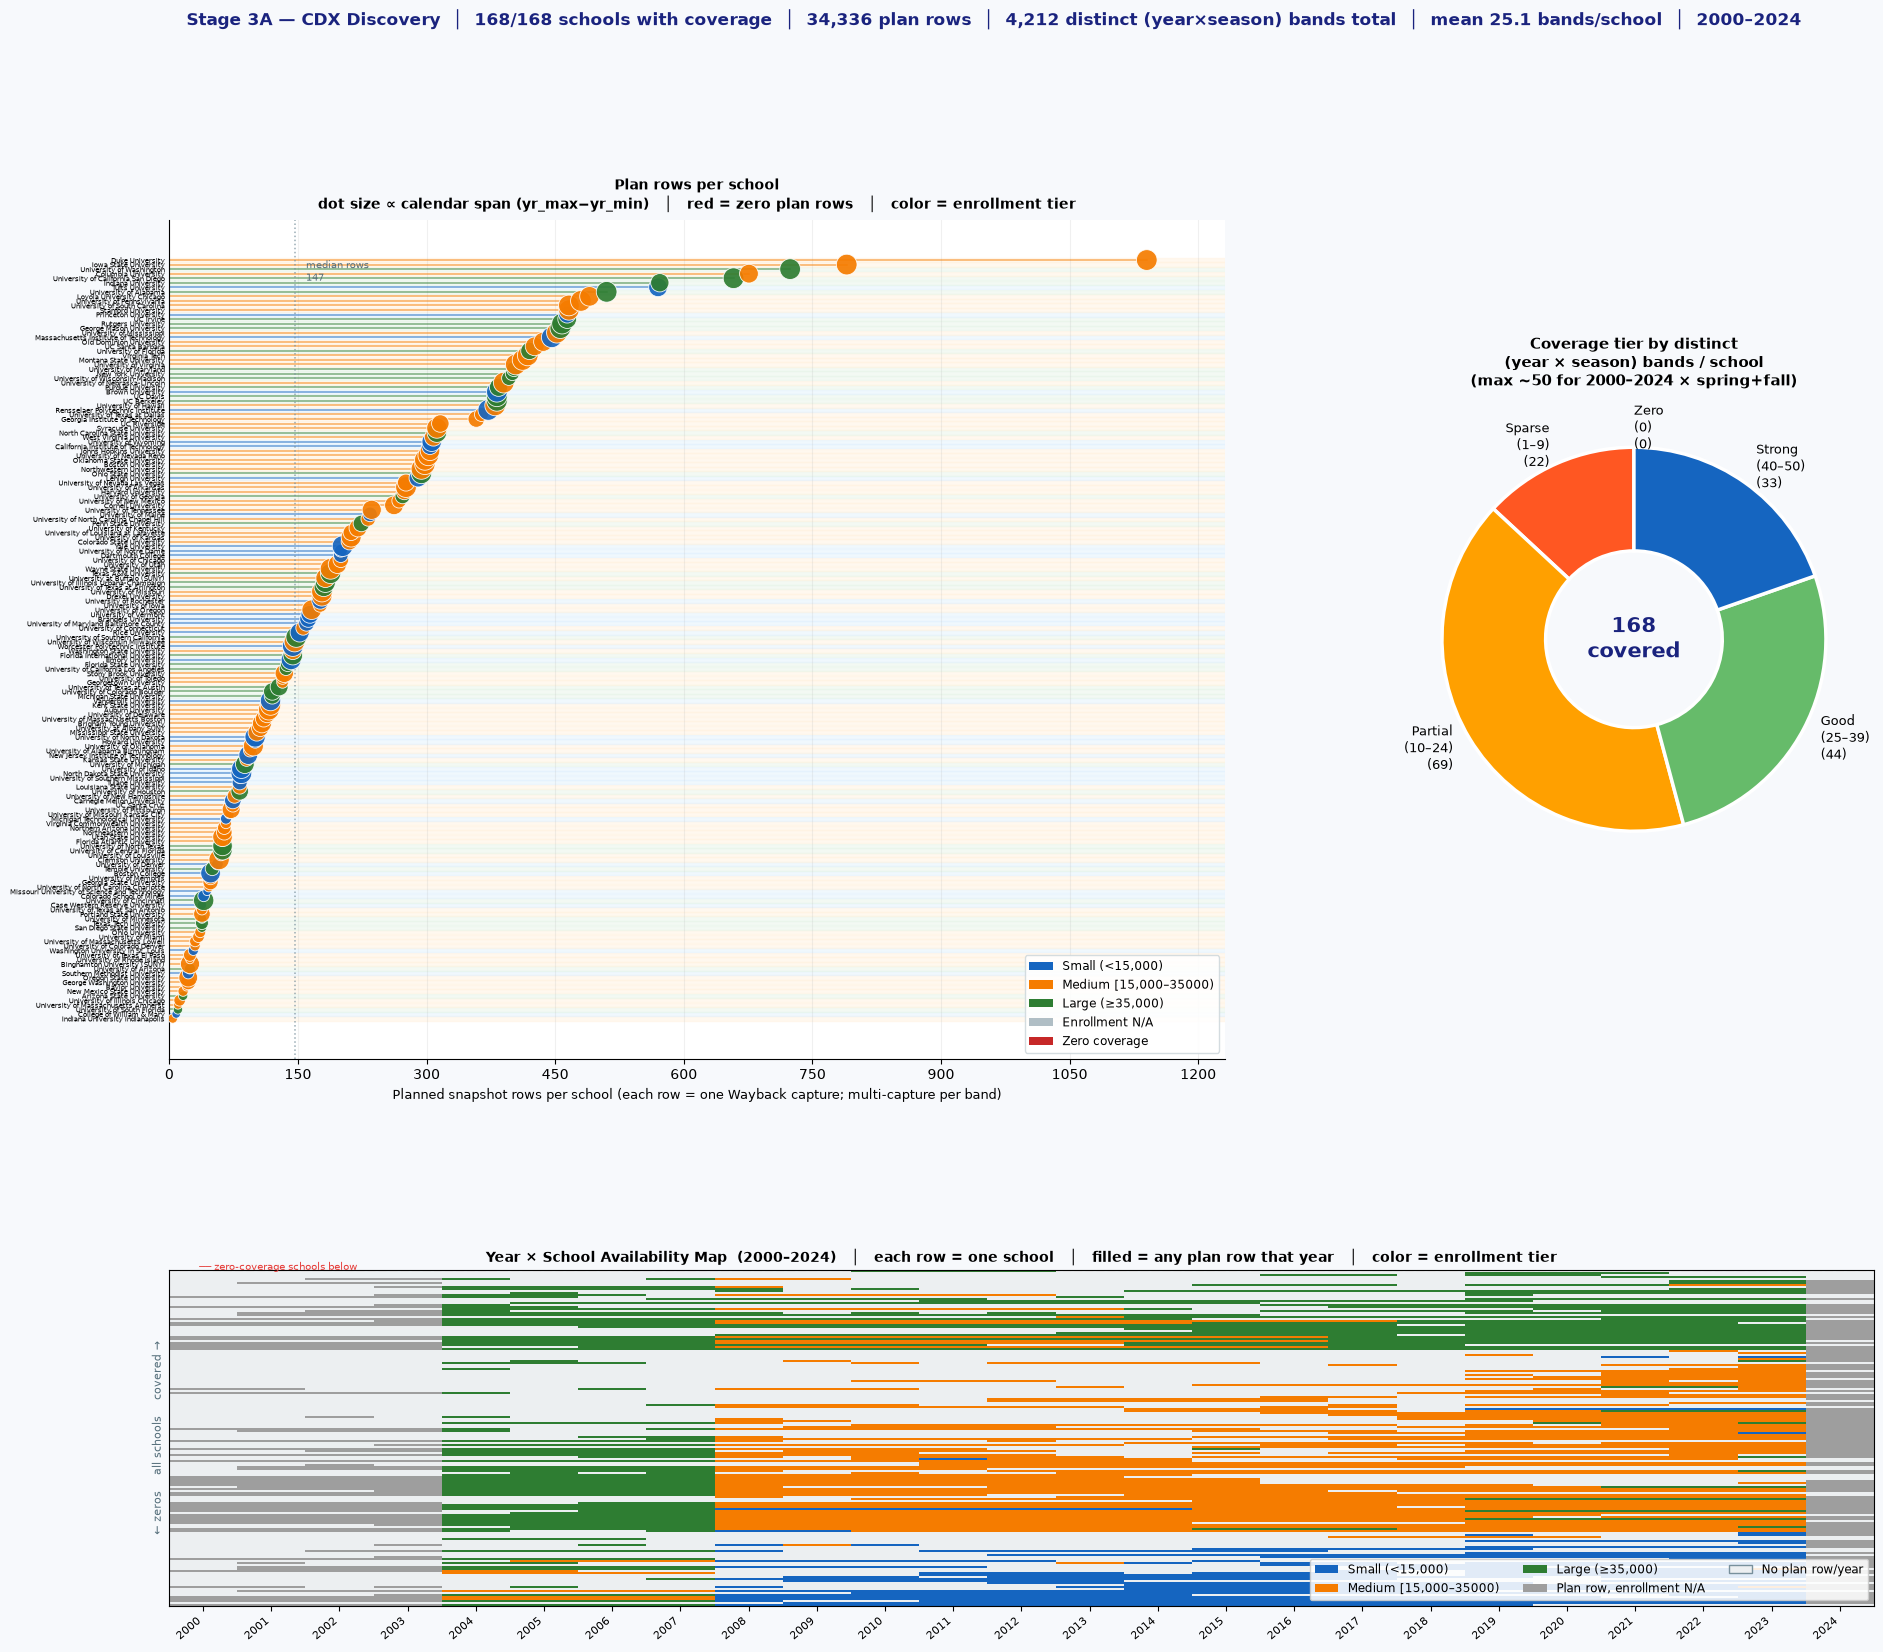

  Saved → /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/tenure/tenure_pipeline/stage3a_summary.png


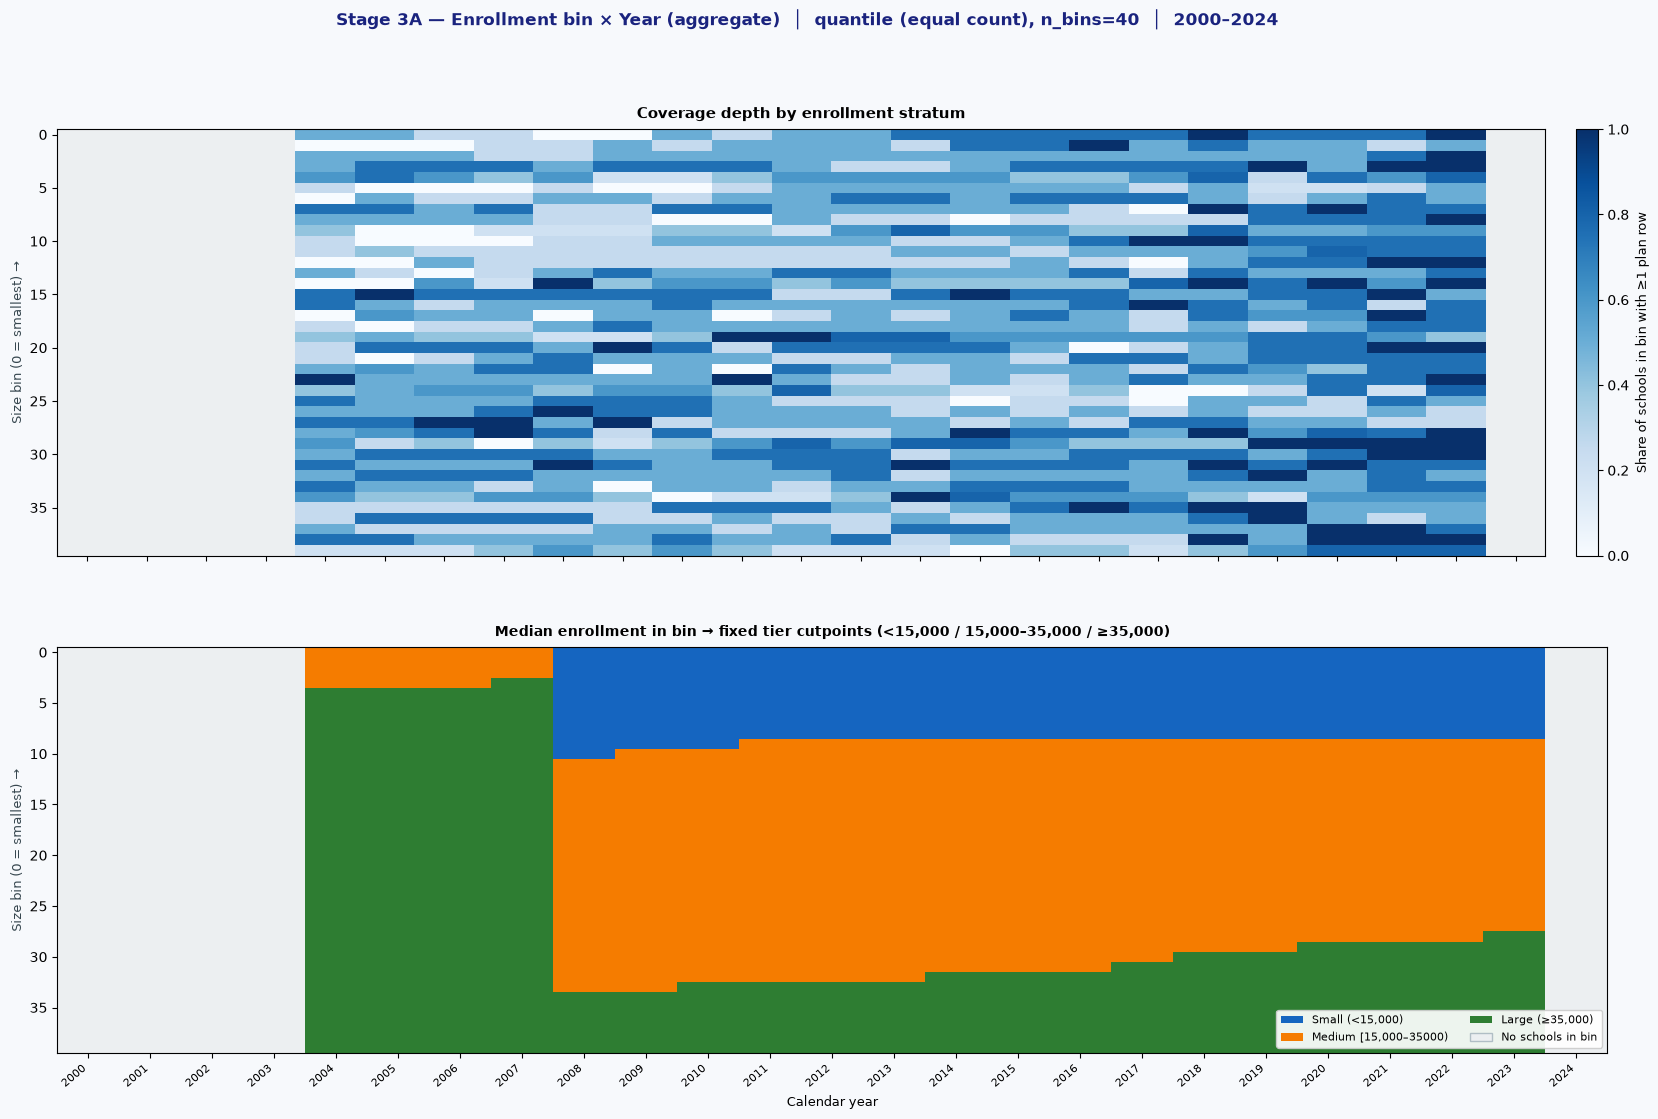

  Saved → /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/tenure/tenure_pipeline/stage3a_enrollment_bin_heatmap.png


In [12]:
# === CELL 3A-VIZ: CDX DISCOVERY — SUMMARY VISUALIZATION ===
# Plotting logic lives in tenure_pipeline/viz_pipeline.py — edit there.
reload_py_files()
import viz_pipeline

VIZ_SCHOOL_SORT = 'volume'  # 'alphabetical' — A→Z on lollipop + Year×School heatmap rows

viz_pipeline.plot_stage3a(
    plan_records = plan_records,
    df_schools   = df_schools,
    cdx_year_min = CDX_YEAR_MIN,
    cdx_year_max = CDX_YEAR_MAX,
    out_path     = TENURE_PIPELINE_DIR / 'stage3a_summary.png',
    plan_path    = STAGE3_PLAN,
    school_sort  = VIZ_SCHOOL_SORT,
    enrollment_path = STAGE3_ENROLLMENT,
)

# Aggregate year × enrollment-size bin (not per-school): coverage share + median tier.
VIZ_ENROLLMENT_BINS = 40  # try 20 for coarser / less noisy
VIZ_ENROLLMENT_BINNING = 'quantile'  # 'equal_width' — fixed enrollment spans; empty bins show as light grey

viz_pipeline.plot_stage3a_enrollment_bin_heatmap(
    plan_records     = plan_records,
    df_schools       = df_schools,
    cdx_year_min     = CDX_YEAR_MIN,
    cdx_year_max     = CDX_YEAR_MAX,
    out_path         = TENURE_PIPELINE_DIR / 'stage3a_enrollment_bin_heatmap.png',
    plan_path        = STAGE3_PLAN,
    enrollment_path  = STAGE3_ENROLLMENT,
    n_bins           = VIZ_ENROLLMENT_BINS,
    binning          = VIZ_ENROLLMENT_BINNING,
)

In [7]:
if RUN_CELL3_COOLDOWN:
    # === CELL 3A→3A-RETRY BRIDGE: cool-down + hourglass ===
    # Run after CELL 3A-VIZ, before CELL 3A-RETRY. Requires CELL 0 (`CDX_SLEEP_BEFORE_RETRY_SEC`).
    import time
    from IPython.display import HTML, display

    display(
        HTML(
            r"""
    <div style="text-align:center;padding:12px 8px 20px;font-family:ui-sans-serif,system-ui,sans-serif;">
    <style>
    @keyframes hg-pulse { 0%,100%{opacity:1;transform:scale(1);} 50%{opacity:0.88;transform:scale(1.04);} }
    .hg-emoji { font-size:min(28vw,140px); line-height:1; animation: hg-pulse 2.2s ease-in-out infinite; }
    .hg-sub { color:#333; margin:10px 0 6px; font-size:1.08rem; }
    .hg-hint { color:#555; font-size:0.95rem; max-width:28em; margin:0 auto; }
    </style>
    <div class="hg-emoji" aria-hidden="true">&#x23F3;</div>
    <p class="hg-sub"><strong>Cool-down before CDX retry pass</strong></p>
    <p class="hg-hint">Sleeping <code>CDX_SLEEP_BEFORE_RETRY_SEC</code> seconds — Internet Archive breather.<br/>Safe to step away; then run <strong>CELL 3A-RETRY</strong> &rarr; <strong>CELL 3B</strong>.</p>
    </div>
    """
        )
    )

    _m = CDX_SLEEP_BEFORE_RETRY_SEC // 60
    _s = CDX_SLEEP_BEFORE_RETRY_SEC % 60
    print(f"Sleeping {_m} min {_s} s ({CDX_SLEEP_BEFORE_RETRY_SEC} s total)…", flush=True)
    time.sleep(CDX_SLEEP_BEFORE_RETRY_SEC)
    print("Cool-down finished — continue with CELL 3A-RETRY, then CELL 3B.", flush=True)


## 🌙 CELL 3A-RETRY: CDX Slow Retry Pass

Overnight retry for URLs that timed out during the fast Cell 3A pass.
Uses a 40-second timeout.  Run this with `RUN_CELL3_RETRY = True` before bed.
Safe to run multiple times — processed URLs are removed from the queue.

In [13]:
# === CELL 3A-RETRY: OVERNIGHT CDX SLOW RETRY ===
# Reads cdx_retry_queue.jsonl (populated by Cell 3A timeouts) and re-queries
# each URL with CDX_RETRY_TIMEOUT (40s).  Run overnight — takes patience
# but squeezes data out of slow Wayback CDX responses.

if RUN_CELL3_RETRY:
    from tenure_pipeline.apply_url_updates import faculty_source_id
    clk = time_start("Stage 3A-RETRY — Overnight CDX Slow Retry")

    if not STAGE3_RETRY.exists():
        print("  No retry queue found — nothing to do.")
    else:
        retry_lines = [l for l in STAGE3_RETRY.read_text(encoding='utf-8').splitlines() if l.strip()]
        retry_queue = [json.loads(l) for l in retry_lines]
        print(f"  Retry queue: {len(retry_queue)} URL(s) to try with {CDX_RETRY_TIMEOUT}s timeout")

        session = requests.Session()
        session.headers.update(CDX_HEADERS)
        from requests.adapters import HTTPAdapter
        _no_retry = HTTPAdapter(max_retries=0)
        session.mount('https://', _no_retry)
        session.mount('http://',  _no_retry)

        remaining   = []   # URLs that still time out — kept for next retry run
        plan_records_loaded = [json.loads(l) for l in STAGE3_PLAN.read_text(encoding='utf-8').splitlines() if l.strip()] if STAGE3_PLAN.exists() else []
        tried_urls  = set()
        for _r in plan_records_loaded:
            for _k in ('source_url', 'tried_primary_url'):
                _u = _r.get(_k)
                if _u: tried_urls.add(_u)

        new_plan_recs = []
        with open(STAGE3_PLAN, 'a', encoding='utf-8') as _pf:
            for _qi, entry in enumerate(retry_queue, 1):
                url      = entry['url']
                uni_name = entry['university']
                uni_slug = entry['uni_slug']

                # Skip if this URL was already resolved by a previous retry run
                if url in tried_urls:
                    print(f"  [{_qi}/{len(retry_queue)}] already resolved: {url[:70]}")
                    continue

                print(f"  [{_qi}/{len(retry_queue)}] querying ({CDX_RETRY_TIMEOUT}s): {url[:70]}", flush=True)

                params = {
                    "url": url, "output": "json",
                    "fl": "timestamp,original,statuscode",
                    "from": f"{CDX_YEAR_MIN}0101", "to": f"{CDX_YEAR_MAX}1231",
                    "filter": ["statuscode:200", "mimetype:text/html"],
                    "collapse": "timestamp:6", "limit": 600,
                }
                try:
                    r = session.get("https://web.archive.org/cdx/search/cdx",
                                    params=params, timeout=CDX_RETRY_TIMEOUT)
                    r.raise_for_status()
                    data = r.json()
                    snaps = [] if len(data) <= 1 else [dict(zip(data[0], row)) for row in data[1:]]
                    tried_urls.add(url)

                    if snaps:
                        selected = _select_seasons(
                            snaps, CDX_YEAR_MIN, CDX_YEAR_MAX, CDX_SEASONS,
                            CDX_SNAPS_PER_SEASON, CDX_SPACING_POOL_MULT,
                        )
                        print(f"    ✓  {len(snaps)} snaps → {len(selected)} selected")
                        src_id = faculty_source_id(url)
                        for sel in selected:
                            wayback_url  = f"https://web.archive.org/web/{sel['timestamp']}/{sel['original']}"
                            out_filename = f"{sel['year']}_{sel['season']}_{sel['timestamp']}.html"
                            out_path     = STAGE3_HTML_DIR / uni_slug / src_id / out_filename
                            _rec = {
                                'university': uni_name, 'uni_slug': uni_slug,
                                'year': sel['year'], 'season': sel['season'],
                                'timestamp': sel['timestamp'],
                                'source_url': url,
                                'source_id': src_id,
                                'wayback_url': wayback_url,
                                'local_path': f"{SNAPSHOT_LOCAL_PREFIX}/{uni_slug}/{src_id}/{out_filename}",
                                'total_snaps_union': len(snaps),
                            }
                            _pf.write(json.dumps(_rec) + '\n')
                            new_plan_recs.append(_rec)
                        _bookmark = {
                            'plan_row_type': 'cdx_bookmark',
                            'university': uni_name,
                            'uni_slug': uni_slug,
                            'source_url': url,
                            'queried_at': time.strftime('%Y-%m-%d'),
                        }
                        _pf.write(json.dumps(_bookmark) + '\n')
                    else:
                        print(f"    ⚠  confirmed empty — sentinel written")
                        _sentinel = {'university': uni_name, 'uni_slug': uni_slug,
                                     'n_snaps': 0, 'source_url': url,
                                     'queried_at': time.strftime('%Y-%m-%d')}
                        _pf.write(json.dumps(_sentinel) + '\n')
                    _pf.flush()

                except Exception as e:
                    print(f"    ⏱  timeout again — keeping in queue: {e}")
                    remaining.append(entry)

                time.sleep(CDX_DELAY)

        # Rewrite retry queue with only the still-unresolved entries
        STAGE3_RETRY.write_text(
            '\n'.join(json.dumps(r) for r in remaining) + ('\n' if remaining else ''),
            encoding='utf-8'
        )
        print(f"\n  Done: {len(new_plan_recs)} new plan records added")
        print(f"  Retry queue remaining: {len(remaining)} URL(s) still timing out")
        if remaining:
            print("  (run again to retry those — Wayback may be more responsive later)")

    time_stop(clk)
else:
    print(f"  CELL 3A-RETRY skipped — set RUN_CELL3_RETRY = True to run  {tymeout()}")


  CELL 3A-RETRY skipped — set RUN_CELL3_RETRY = True to run  19:26:05 (EST) Fri, 02 Oct 2026


## 📥 CELL 3B: STAGE 3B — Wayback HTML Download

##### **Purpose**: Fetch raw HTML for each row in `faculty_snapshots_plan.jsonl` from the Internet Archive and save it on disk for Cell 4 parsing.
##### **Input**: `tenure_pipeline/faculty_snapshots_plan.jsonl` (from CELL 3A / 3A-RETRY)
##### **Output**: HTML files under the logical tree `tenure_pipeline/faculty_snapshots/<uni_slug>/<source_id>/…html`. On disk, 3B writes to **FACULTY_SNAPSHOTS_WRITE_ROOT** in CELL 0 — set **FACULTY_SNAPSHOTS_WRITE_ROOT_MODE** to `"desktop"` (default → `~/Desktop/faculty_snapshots`), `"workspace"`, or `"temp"`. **faculty_snapshot_search_roots()** finds files across write root, `STAGE3_HTML_DIR`, workspace, Desktop. Append-only log: `tenure_pipeline/faculty_snapshots_index.jsonl` (one JSON line per attempt).
##### **Run**: Set `RUN_CELL3_DOWNLOAD = True` in CELL 0. Requires CELL 0 imports and `requests` session headers (`CDX_HEADERS`).

**Checkpoint/resume**: Skips when a snapshot file already exists with ≥500 bytes readable bytes on any search root (write root, workspace `faculty_snapshots`, Desktop mirror). **Rate limit**: `CDX_DELAY` between requests; HTTP 429 backs off 60s.

**Empty or blocked captures**: Wayback sometimes returns HTTP 200 with an empty body (`too small`), or HTTP 403 — those are archive-side, not skip-logic bugs.


In [15]:
# === CELL 3B: STAGE 3B — WAYBACK HTML DOWNLOAD ===
# Requires CELL 0 (imports `os`, `time`, `json`, `Path`, …).
# Downloads each planned snapshot from the Wayback Machine and saves raw HTML.
# Checkpoint/resume: skips when HTML already exists on disk (≥ MIN_HTML_BYTES).
#
# Index vs disk (skip decision uses disk only):
#   • Old logic required local_path in the index AND a file on disk. The file check was
#     already what stopped repeat downloads when the index said OK but the file was gone.
#   • Requiring the index could skip the wrong way the other direction: HTML present but
#     not yet in the index (restored/copied files) would re-fetch unnecessarily.
#   • We still read the index below for a ghost warning (200 in log, no usable file) and
#     still append one JSON line per attempt — audit trail unchanged.
#
# Appends one record to faculty_snapshots_index.jsonl after each attempt.
# Rate: CDX_DELAY seconds between requests. Handles 429 with 60s backoff.
#
# overwrite examples:
#   None / False                          → skip files already on disk
#   True                                  → re-download all planned snapshots
#   ['princeton_university/2015/fall']    → re-download specific slug/year/season keys

MIN_HTML_BYTES = 500  # files smaller than this are treated as empty/redirect errors
# Large Wayback pages (e.g. ASU cidse ~400KB): write+verify under $TMPDIR then copy into faculty_snapshots (Dropbox in-place writes can vanish).
LARGE_HTML_STAGING_BYTES = 150_000


def _wayback_insert_id_modifier(url: str) -> str:
    """Insert Wayback id_ replay modifier after the 14-digit timestamp (raw replay; sometimes non-empty when default is empty)."""
    m = re.match(r"^(https://web\.archive\.org/web/)(\d{14})(/)(https?://.+)$", url, re.I)
    if not m:
        return url
    return f"{m.group(1)}{m.group(2)}id_{m.group(3)}{m.group(4)}"


def _snapshot_file_ok(lp: str) -> bool:
    """True if local_path exists with >= MIN_HTML_BYTES readable bytes under any faculty_snapshot_search_roots() (temp, workspace, Desktop)."""
    if not lp or not str(lp).strip():
        return False
    rel = _faculty_snapshot_rel_from_local_path(lp)
    if rel is None:
        op = resolve_faculty_snapshot_path(lp)
        try:
            if not op.is_file():
                return False
            if op.stat().st_size >= MIN_HTML_BYTES:
                return True
            with open(op, "rb") as _rf:
                return len(_rf.read(MIN_HTML_BYTES + 1)) >= MIN_HTML_BYTES
        except OSError:
            return False
    for root in faculty_snapshot_search_roots():
        op = (root / rel).resolve()
        try:
            if not op.is_file():
                continue
            if op.stat().st_size >= MIN_HTML_BYTES:
                return True
            with open(op, "rb") as _rf:
                if len(_rf.read(MIN_HTML_BYTES + 1)) >= MIN_HTML_BYTES:
                    return True
        except OSError:
            continue
    return False


def _write_bytes_via_shell_if_eperm(path: Path, content: bytes) -> bool:
    """When ``Path.write_bytes`` raises EPERM (errno 1): Cursor/Jupyter sandbox often blocks Dropbox writes.

    Delegates to ``/bin/sh`` or ``/usr/bin/python3`` — same mechanism that works from Terminal.
    Returns True if *path* exists afterward with size ``len(content)``.
    """
    import shlex
    import subprocess

    sp = str(path)
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
    except OSError:
        pass
    try:
        r = subprocess.run(
            ["/bin/sh", "-c", f"cat > {shlex.quote(sp)}"],
            input=content,
            capture_output=True,
            timeout=300,
        )
        if r.returncode == 0:
            try:
                if path.is_file() and path.stat().st_size == len(content):
                    return True
            except OSError:
                pass
    except Exception:
        pass
    py = "/usr/bin/python3"
    if not Path(py).is_file():
        return False
    try:
        r = subprocess.run(
            [
                py,
                "-c",
                "import sys, pathlib; p=pathlib.Path(sys.argv[1]); "
                "p.parent.mkdir(parents=True, exist_ok=True); "
                "p.write_bytes(sys.stdin.buffer.read())",
                sp,
            ],
            input=content,
            capture_output=True,
            timeout=300,
        )
        if r.returncode == 0:
            try:
                if path.is_file() and path.stat().st_size == len(content):
                    return True
            except OSError:
                pass
    except Exception:
        pass
    return False


def _read_bytes_verify_via_subprocess(path: Path, content: bytes, *, quiet: bool = False) -> bool:
    """When kernel ``read_bytes``/``stat`` fail (Cursor sandbox + Dropbox), verify without in-process I/O.

    Order: ``/bin/cat`` (byte match) → ``openssl dgst -sha256`` / ``shasum`` (hash match) → ``stat -f %z`` (size-only, weak).
    """
    import hashlib
    import re
    import shlex
    import subprocess

    sp = str(path)
    want_len = len(content)
    want_sha = hashlib.sha256(content).hexdigest()

    try:
        r = subprocess.run(
            ["/bin/cat", sp],
            capture_output=True,
            timeout=120,
        )
        if r.returncode == 0 and r.stdout == content and len(r.stdout) >= MIN_HTML_BYTES:
            if not quiet:
                print("     NOTE: kernel read failed; verified via /bin/cat.", flush=True)
            return True
    except Exception:
        pass

    try:
        r = subprocess.run(
            ["/usr/bin/openssl", "dgst", "-sha256", sp],
            capture_output=True,
            text=True,
            timeout=120,
        )
        if r.returncode == 0 and r.stdout:
            m = re.search(r"= ([0-9a-f]{64})", r.stdout, re.I)
            if m and m.group(1).lower() == want_sha:
                if not quiet:
                    print("     NOTE: kernel read failed; verified via openssl SHA256.", flush=True)
                return True
    except Exception:
        pass

    try:
        r = subprocess.run(
            ["/bin/sh", "-c", f"shasum -a 256 {shlex.quote(sp)}"],
            capture_output=True,
            text=True,
            timeout=120,
        )
        if r.returncode == 0 and r.stdout:
            tok = r.stdout.strip().split()
            if tok and tok[0].lower() == want_sha:
                if not quiet:
                    print("     NOTE: kernel read failed; verified via shasum SHA256.", flush=True)
                return True
    except Exception:
        pass

    try:
        r = subprocess.run(
            ["/usr/bin/stat", "-f", "%z", sp],
            capture_output=True,
            text=True,
            timeout=30,
        )
        if r.returncode == 0 and r.stdout.strip().isdigit():
            if int(r.stdout.strip()) == want_len and want_len >= MIN_HTML_BYTES:
                if not quiet:
                    print(
                        "     NOTE: kernel cannot stat/read file; subprocess stat size only — weak verify.",
                        flush=True,
                    )
                return True
    except Exception:
        pass

    return False


def _install_large_html_via_temp_staging(dest: Path, content: bytes) -> bool:
    """Write large HTML to ``$TMPDIR/...``, verify, then ``cp`` into *dest* (mitigates Dropbox in-place glitches)."""
    import hashlib
    import shutil
    import subprocess

    if len(content) < LARGE_HTML_STAGING_BYTES:
        return False

    td = Path(tempfile.gettempdir()) / "faculty_snapshots_3b_staging"
    try:
        td.mkdir(parents=True, exist_ok=True)
    except OSError:
        return False

    name = f"{hashlib.sha256(str(dest).encode()).hexdigest()[:12]}_{dest.name}"
    tmp = td / name
    try:
        try:
            tmp.write_bytes(content)
        except OSError:
            if not _write_bytes_via_shell_if_eperm(tmp, content):
                return False
        ok_tmp = False
        try:
            ok_tmp = tmp.read_bytes() == content
        except OSError:
            ok_tmp = _read_bytes_verify_via_subprocess(tmp, content, quiet=True)
        if not ok_tmp:
            try:
                tmp.unlink(missing_ok=True)
            except OSError:
                pass
            return False

        dest.parent.mkdir(parents=True, exist_ok=True)
        try:
            shutil.copy2(tmp, dest)
        except OSError:
            r = subprocess.run(
                ["/bin/cp", str(tmp), str(dest)],
                capture_output=True,
                timeout=120,
            )
            if r.returncode != 0:
                try:
                    tmp.unlink(missing_ok=True)
                except OSError:
                    pass
                return False

        try:
            tmp.unlink(missing_ok=True)
        except OSError:
            pass

        ok_dest = False
        try:
            ok_dest = dest.read_bytes() == content
        except OSError:
            ok_dest = _read_bytes_verify_via_subprocess(dest, content, quiet=True)
        if ok_dest:
            print(
                "     NOTE: large HTML staged in $TMPDIR then copied — avoids Dropbox in-place vanish.",
                flush=True,
            )
            return True
        if _read_bytes_verify_via_subprocess(dest, content, quiet=False):
            print(
                "     NOTE: large HTML staged in $TMPDIR; destination verified via subprocess only.",
                flush=True,
            )
            return True
        return False
    except Exception:
        return False


def _download_plan(plan_path, index_path, session, delay, overwrite):
    """Core download loop — reads plan JSONL, fetches HTML, appends to index JSONL."""
    with open(plan_path, encoding='utf-8') as f:
        raw_plan = [json.loads(line) for line in f]

    # Per-uni_slug block from failure sentinels (n_snaps==-1 plus a reason: Cell 3B all-fail, Cell 4 condemn).
    # Scan the full JSONL in order; a later real snapshot row clears the block. We must do this *before*
    # stripping sentinels — otherwise the download loop never sees n_snaps=-1 lines and keeps re-fetching.
    # CDX bookmarks use plan_row_type==cdx_bookmark (not n_snaps=-1).
    _plan_block_slug = {}
    for r in raw_plan:
        us = r.get('uni_slug')
        if not us:
            continue
        has_real = (
            r.get('local_path')
            and r.get('year') is not None
            and r.get('season')
            and r.get('n_snaps', 1) > 0
        )
        if has_real:
            _plan_block_slug[us] = False
        elif r.get('n_snaps') == -1 and r.get('reason'):
            _plan_block_slug[us] = True

    # Strip sentinel records (n_snaps <= 0) and CDX bookmark rows (plan_row_type=cdx_bookmark).
    plan = [
        r for r in raw_plan
        if r.get('plan_row_type') != 'cdx_bookmark'
        and r.get('n_snaps', 1) > 0
    ]

    # Slugs may be blocked by a trailing failure sentinel (handled below).

    # Ghost index rows: HTTP 200 + size OK in the log, but no usable file on disk (sync/interrupt/move).
    _ghost_ok = []
    if Path(index_path).exists():
        with open(index_path, encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                rec = json.loads(line)
                if rec.get('http_status') != 200:
                    continue
                if rec.get('file_size_bytes', 0) < MIN_HTML_BYTES:
                    continue
                lp = rec.get('local_path')
                if not lp:
                    continue
                if not _snapshot_file_ok(lp):
                    _ghost_ok.append(lp)
    if _ghost_ok:
        _uniq = list(dict.fromkeys(_ghost_ok))
        print(f"  WARNING: {len(_uniq)} index row(s) claim success but HTML is missing or < {MIN_HTML_BYTES} B on disk (all faculty_snapshot_search_roots() in CELL 0).")
        print("           Re-fetching those paths. If this WARNING returns every run, files may be cloud placeholders")
        print("           (Dropbox / iCloud) or only under another root — CELL 0 resolves faculty_snapshot_search_roots().")
        print("           Or writes failed with EPERM in the notebook kernel (Cursor sandbox) — 3B tries a shell bypass after write_bytes.")
        _show = _uniq[:8]
        for _g in _show:
            print(f"           — {_g}")
        if len(_uniq) > len(_show):
            print(f"           … ({len(_uniq) - len(_show)} more)")

    # Normalize overwrite parameter
    force_all = overwrite is True
    if force_all:
        overwrite_keys = set()
    elif isinstance(overwrite, list):
        overwrite_keys = set(overwrite)
    else:
        overwrite_keys = set()

    # Partition into skip / download (on-disk artifact is the primary skip signal; plan sentinel blocks below)
    to_download = []
    n_skipped   = 0
    n_plan_dup  = 0
    n_plan_blk  = 0
    _blocked_slugs = set()
    _seen_lp = set()
    for rec in plan:
        lp = rec.get('local_path')
        if not lp:
            continue
        if _plan_block_slug.get(rec['uni_slug'], False):
            n_plan_blk += 1
            _blocked_slugs.add(rec['uni_slug'])
            continue
        key_legacy = f"{rec['uni_slug']}/{rec['year']}/{rec['season']}"
        already  = (
            (not force_all) and
            _snapshot_file_ok(lp) and
            lp not in overwrite_keys and
            key_legacy not in overwrite_keys
        )
        if already:
            n_skipped += 1
        elif lp in _seen_lp:
            n_plan_dup += 1
        else:
            _seen_lp.add(lp)
            to_download.append(rec)

    print(f"  Plan total       : {len(plan):>6,}")
    print(f"  Blocked (plan)   : {n_plan_blk:>6,}  (failure sentinel: n_snaps=-1 with reason)")
    print(f"  Duplicate paths  : {n_plan_dup:>6,}  (same local_path repeated in plan — skipped)")
    if _blocked_slugs:
        _bs = ', '.join(sorted(_blocked_slugs)[:10])
        _more = f" (+{len(_blocked_slugs) - 10} more)" if len(_blocked_slugs) > 10 else ''
        print(f"                     {_bs}{_more}")
    print(f"  Already on disk  : {n_skipped:>6,}")
    print(f"  To download      : {len(to_download):>6,}")

    if not to_download:
        print("  Nothing to do — all snapshots already present.")
        return

    n_ok         = 0
    n_err        = 0
    n_total      = len(to_download)
    _total_bytes = 0
    _cur_uni     = None
    _uni_ok      = 0
    _uni_err     = 0
    _uni_bytes   = 0
    _uni_n_snaps = 0

    def _fmt(b):
        """Format a byte count as a human-readable KB / MB / GB string."""
        if b < 1_048_576:        return f"{b/1024:.1f} KB"
        if b < 1_073_741_824:    return f"{b/1_048_576:.2f} MB"
        return f"{b/1_073_741_824:.2f} GB"

    # pre-compute per-school snap counts so the banner doesn't loop over the full list each time
    from collections import Counter as _Counter
    _snaps_per_uni = _Counter(r['university'] for r in to_download)

    with open(index_path, 'a', encoding='utf-8') as idx_f:
        for _dl_i, rec in enumerate(tqdm(to_download, desc="Downloading", unit="snap"), start=1):
            out_path = resolve_faculty_snapshot_path(rec['local_path'], for_write=True).resolve()
            out_path.parent.mkdir(parents=True, exist_ok=True)

            # School transition — print summary of finished school, banner for new one
            if rec['university'] != _cur_uni:
                if _cur_uni is not None:
                    _rate   = 100 * _uni_ok / (_uni_ok + _uni_err) if (_uni_ok + _uni_err) else 0
                    _avg_kb = (_uni_bytes / 1024 / _uni_ok) if _uni_ok else 0
                    print(f"  └─ {_cur_uni}:  {_uni_ok}/{_uni_n_snaps} OK  ({_rate:.0f}%)  avg {_avg_kb:.1f} KB/file  │  {_fmt(_uni_bytes)} this school", flush=True)
                _cur_uni     = rec['university']
                _uni_ok      = 0
                _uni_err     = 0
                _uni_bytes   = 0
                _uni_n_snaps = _snaps_per_uni[_cur_uni]
                _pct         = 100 * (_dl_i - 1) / n_total
                print(f"\n  ── Now downloading: {_cur_uni}  ({_uni_n_snaps} snaps)"
                      f"  │  overall: {_dl_i-1:,}/{n_total:,} ({_pct:.1f}%)  {n_ok:,} ✓  {n_err} ✗  │  {_fmt(_total_bytes)} so far", flush=True)

            print(f"     {rec['year']} {rec['season']}  →  {rec['wayback_url']}", flush=True)

            http_status     = -1
            file_size_bytes = 0
            error_msg       = ''

            try:
                r           = session.get(rec['wayback_url'], timeout=CDX_HTML_TIMEOUT)
                http_status = r.status_code

                if http_status == 429:
                    print("\n  WARNING: 429 rate limit — sleeping 60s then retrying", flush=True)
                    time.sleep(60)
                    r           = session.get(rec['wayback_url'], timeout=CDX_HTML_TIMEOUT)
                    http_status = r.status_code

                if http_status == 200:
                    content         = r.content
                    # Default Wayback replay sometimes returns HTTP 200 with an empty body; id_ raw replay can differ.
                    if len(content) < MIN_HTML_BYTES:
                        _alt = _wayback_insert_id_modifier(rec["wayback_url"])
                        if _alt != rec["wayback_url"]:
                            try:
                                r2 = session.get(_alt, timeout=CDX_HTML_TIMEOUT)
                                if r2.status_code == 200 and len(r2.content) >= MIN_HTML_BYTES:
                                    r = r2
                                    content = r.content
                            except Exception:
                                pass
                    file_size_bytes = len(content)
                    if file_size_bytes >= MIN_HTML_BYTES:
                        # Write + read-back verify. If primary root hits EPERM (errno 1), retry once under workspace
                        # …/tenure/tenure_pipeline/faculty_snapshots (same relpath) — common fix for Desktop/$TMPDIR sandbox.
                        _wp0 = out_path.resolve()
                        _rel_lp = _faculty_snapshot_rel_from_local_path(rec["local_path"])
                        _ws = (
                            (TENURE_PIPELINE_DIR / "faculty_snapshots" / _rel_lp).resolve()
                            if _rel_lp
                            else None
                        )
                        _paths_try = [_wp0]
                        if _ws is not None and _ws.resolve() != _wp0.resolve():
                            _paths_try.append(_ws)
                        _ok_write = False
                        _err = ""
                        _wp = _wp0
                        for _pi, _wpx in enumerate(_paths_try):
                            try:
                                _wpx.parent.mkdir(parents=True, exist_ok=True)
                                try:
                                    _wpx.write_bytes(content)
                                except OSError as _we0:
                                    if getattr(_we0, "errno", None) == 1:
                                        if _write_bytes_via_shell_if_eperm(_wpx, content):
                                            print(
                                                "     NOTE: EPERM on kernel write_bytes — wrote via shell/system python (sandbox bypass).",
                                                flush=True,
                                            )
                                        else:
                                            raise _we0
                                    else:
                                        raise
                                try:
                                    _fd = os.open(str(_wpx), os.O_RDWR)
                                    try:
                                        os.fsync(_fd)
                                    finally:
                                        os.close(_fd)
                                except OSError:
                                    pass
                            except OSError as _wexc:
                                _err = f"write failed: {_wexc}"
                                if getattr(_wexc, "errno", None) == 1 and _pi + 1 < len(_paths_try):
                                    print(
                                        "     NOTE: EPERM on write — retrying under workspace tenure/tenure_pipeline/faculty_snapshots …",
                                        flush=True,
                                    )
                                    continue
                                break
                            else:
                                _wp = _wpx
                                for _attempt in range(200):
                                    try:
                                        _got = _wpx.read_bytes()
                                        if _got == content and len(_got) >= MIN_HTML_BYTES:
                                            _ok_write = True
                                            break
                                    except OSError:
                                        pass
                                    time.sleep(0.05)
                                if not _ok_write and _read_bytes_verify_via_subprocess(_wpx, content):
                                    _ok_write = True
                                if not _ok_write:
                                    try:
                                        _ds = _wpx.stat().st_size
                                    except OSError:
                                        _ds = -1
                                    try:
                                        _rlen = len(_wpx.read_bytes())
                                    except OSError:
                                        _rlen = -1
                                    _err = f"read-back verify failed (expected {file_size_bytes} B; read {_rlen} B; stat {_ds} B) @ {_wpx}"
                                    if _ds < 0 and _rlen < 0:
                                        _err += f" — missing after write (3B root={FACULTY_SNAPSHOTS_WRITE_ROOT})."
                                break
                        if not _ok_write:
                            error_msg = _err or "verify failed"
                            n_err    += 1
                            _uni_err += 1
                            file_size_bytes = 0
                            print(f"     ✗ {error_msg}"
                                  f"  │  overall: {n_ok:,} ✓  {n_err} ✗  of {_dl_i:,}/{n_total:,}", flush=True)
                        else:
                            n_ok         += 1
                            _uni_ok      += 1
                            _uni_bytes   += file_size_bytes
                            _total_bytes += file_size_bytes
                            print(f"     ✓ {file_size_bytes/1024:.1f} KB"
                                  f"  │  {_cur_uni[:30]}: {_uni_ok}/{_uni_n_snaps}"
                                  f"  │  overall: {n_ok:,} ✓  {n_err} ✗  of {_dl_i:,}/{n_total:,}  │  {_fmt(_total_bytes)} total", flush=True)
                    else:
                        error_msg = f"too small ({file_size_bytes} bytes) — Wayback empty body; pick another timestamp in 3A or capture may be gone"
                        n_err    += 1
                        _uni_err += 1
                        print(f"     ✗ too small ({file_size_bytes}B)"
                              f"  │  overall: {n_ok:,} ✓  {n_err} ✗  of {_dl_i:,}/{n_total:,}", flush=True)
                else:
                    error_msg = f"HTTP {http_status}"
                    n_err    += 1
                    _uni_err += 1
                    print(f"     ✗ HTTP {http_status}"
                          f"  │  overall: {n_ok:,} ✓  {n_err} ✗  of {_dl_i:,}/{n_total:,}", flush=True)

            except Exception as e:
                error_msg = str(e)[:80]
                n_err    += 1
                _uni_err += 1
                print(f"     ✗ {str(e)[:60]}"
                      f"  │  overall: {n_ok:,} ✓  {n_err} ✗  of {_dl_i:,}/{n_total:,}", flush=True)

            idx_f.write(json.dumps({
                'university'     : rec['university'],
                'uni_slug'       : rec['uni_slug'],
                'year'           : rec['year'],
                'season'         : rec['season'],
                'timestamp'      : rec['timestamp'],
                'source_url'     : rec['source_url'],
                'wayback_url'    : rec['wayback_url'],
                'local_path'     : rec['local_path'],
                'http_status'    : http_status,
                'file_size_bytes': file_size_bytes,
                'error'          : error_msg,
                'downloaded_at'  : datetime.now().isoformat(),
            }) + '\n')
            idx_f.flush()

            time.sleep(delay)

    # Final school summary (last school has no "next school" to trigger it)
    if _cur_uni is not None:
        _rate   = 100 * _uni_ok / (_uni_ok + _uni_err) if (_uni_ok + _uni_err) else 0
        _avg_kb = (_uni_bytes / 1024 / _uni_ok) if _uni_ok else 0
        print(f"  └─ {_cur_uni}:  {_uni_ok}/{_uni_n_snaps} OK  ({_rate:.0f}%)  avg {_avg_kb:.1f} KB/file", flush=True)

    print(f"\n  Downloaded OK    : {n_ok:>6,}  ({100*n_ok/n_total:.1f}%)")
    print(f"  Errors           : {n_err:>6,}  ({100*n_err/n_total:.1f}%)")
    print(f"  Total data       : {_fmt(_total_bytes)}")
    print(f"  Index            : {Path(index_path).resolve()}")


if RUN_CELL3_DOWNLOAD:
    if not STAGE3_PLAN.exists():
        print(f"  ERROR: No download plan found at {STAGE3_PLAN}")
        print("  Run CELL 3A first — set RUN_CELL3_CDX = True in CELL 0.")
    else:
        clk = time_start("Stage 3B — Wayback HTML Download")

        session = requests.Session()
        session.headers.update(CDX_HEADERS)

        try:
            if "Desktop" in str(STAGE3_HTML_DIR.resolve()):
                print("  NOTE: STAGE3_HTML_DIR is under Desktop. If macOS syncs Desktop & Documents to iCloud,")
                print("        verification can fail until files are fully local. System Settings → Apple ID → iCloud → iCloud Drive → Options → Desktop & Documents.")
        except Exception:
            pass

        _download_plan(
            plan_path      = STAGE3_PLAN,
            index_path     = STAGE3_INDEX,
            session        = session,
            delay          = CDX_DELAY,
            overwrite      = None,
        )

        # Post-download: write bad sentinels for schools where every single
        # download attempt failed (nothing usable landed on disk).
        # Without this, Cell 3A would re-query them on every future run.
        if STAGE3_INDEX.exists():
            with open(STAGE3_INDEX, encoding='utf-8') as _idx_f:
                _idx_recs = [json.loads(l) for l in _idx_f if l.strip()]
            from collections import defaultdict as _dd
            _uni_ok  = _dd(int)   # uni_name → count of successful downloads
            _uni_pri = {}         # uni_name → primary URL (for sentinel)
            for _ir in _idx_recs:
                _uni_ok[_ir['university']] += (1 if _ir.get('http_status') == 200
                                                  and _ir.get('file_size_bytes', 0) >= MIN_HTML_BYTES
                                                  else 0)
            # Cross-reference with plan to find primary URLs
            with open(STAGE3_PLAN, encoding='utf-8') as _pf:
                _plan_recs = [json.loads(l) for l in _pf if l.strip()]
            # primary URL = source_url of the first real plan record for each school
            for _pr in _plan_recs:
                _u = _pr.get('university', '')
                if (_u and _u not in _uni_pri and _pr.get('n_snaps', 1) > 0
                        and _pr.get('plan_row_type') != 'cdx_bookmark'):
                    _uni_pri[_u] = _pr.get('source_url', '')

            # Find schools that were planned but have 0 successful downloads
            _planned_unis = {
                r['university'] for r in _plan_recs
                if r.get('n_snaps', 1) > 0 and r.get('plan_row_type') != 'cdx_bookmark'
            }
            _all_fail     = [u for u in _planned_unis if _uni_ok.get(u, 0) == 0]

            if _all_fail:
                print(f"\n  Writing bad sentinels for {len(_all_fail)} all-fail school(s):")
                with open(STAGE3_PLAN, 'a', encoding='utf-8') as _sf:
                    for _u in sorted(_all_fail):
                        _slug = (_u.lower()
                                 .replace(' ', '_').replace('-', '_')
                                 .replace(',', '').replace('.', ''))
                        _sentinel = {
                            'university':        _u,
                            'uni_slug':          _slug,
                            'n_snaps':           -1,
                            'tried_primary_url': _uni_pri.get(_u, ''),
                            'tried_urls':        [],
                            'queried_at':        time.strftime('%Y-%m-%d'),
                            'reason':            'Cell 3B: all downloads failed (404/403/too-small)',
                        }
                        _sf.write(json.dumps(_sentinel) + '\n')
                        print(f"    ⚠  {_u}")

        time_stop(clk)

else:
    if STAGE3_INDEX.exists():
        with open(STAGE3_INDEX, encoding='utf-8') as f:
            index_records = [json.loads(line) for line in f]
        n_ok = sum(1 for r in index_records if r.get('http_status') == 200)
        print(f"  CELL 3B skipped — {len(index_records):,} downloads in index ({n_ok:,} OK)  {tymeout()}")
    else:
        index_records = []
        print(f"  CELL 3B skipped — no index found yet; set RUN_CELL3_DOWNLOAD = True to run  {tymeout()}")

Start Stage 3B — Wayback HTML Download at 20:39:00 (EST) Fri, 02 Oct 2026
           Re-fetching those paths. If this WARNING returns every run, files may be cloud placeholders
           (Dropbox / iCloud) or only under another root — CELL 0 resolves faculty_snapshot_search_roots().
           Or writes failed with EPERM in the notebook kernel (Cursor sandbox) — 3B tries a shell bypass after write_bytes.
           — tenure_pipeline/faculty_snapshots/arizona_state_university/a9a13703/2019_spring_20191207132919.html
           — tenure_pipeline/faculty_snapshots/arizona_state_university/a9a13703/2019_fall_20191207132919.html
           — tenure_pipeline/faculty_snapshots/arizona_state_university/a9a13703/2020_spring_20200815041620.html
           — tenure_pipeline/faculty_snapshots/arizona_state_university/a9a13703/2020_spring_20201023044909.html
           — tenure_pipeline/faculty_snapshots/arizona_state_university/a9a13703/2020_spring_20201124175704.html
           — tenure_pipeline

Downloading:   0%|          | 0/22 [00:00<?, ?snap/s]


  ── Now downloading: Michigan State University  (2 snaps)  │  overall: 0/22 (0.0%)  0 ✓  0 ✗  │  0.0 KB so far
     2004 spring  →  https://web.archive.org/web/20040310065526/http://www.cse.msu.edu:80/people/faculty/
     ✗ too small (0B)  │  overall: 0 ✓  1 ✗  of 1/22
     2004 fall  →  https://web.archive.org/web/20040310065526/http://www.cse.msu.edu:80/people/faculty/
     ✗ too small (0B)  │  overall: 0 ✓  2 ✗  of 2/22
  └─ Michigan State University:  0/2 OK  (0%)  avg 0.0 KB/file  │  0.0 KB this school

  ── Now downloading: Tufts University  (2 snaps)  │  overall: 2/22 (9.1%)  0 ✓  2 ✗  │  0.0 KB so far
     2019 spring  →  https://web.archive.org/web/20190917090208/https://www.cs.tufts.edu/
     ✗ too small (0B)  │  overall: 0 ✓  3 ✗  of 3/22
     2019 fall  →  https://web.archive.org/web/20190917090208/https://www.cs.tufts.edu/
     ✗ too small (0B)  │  overall: 0 ✓  4 ✗  of 4/22
  └─ Tufts University:  0/2 OK  (0%)  avg 0.0 KB/file  │  0.0 KB this school

  ── Now downloadin

## 📊 CELL 3B-VIZ: HTML Download — Summary Visualization

One-figure rollup of the Wayback download run:
- **Top-left:** Per-school stacked bars — OK (colored by wave) vs errors (hatched red), with % success rate
- **Top-right:** Donut — download status breakdown by error type
- **Bottom-left:** File size violin + jittered strip plot by wave (log scale) — shows page richness distribution
- **Bottom-right:** Cumulative file size CDFs by wave — clean signature of whether wave cohorts differ in page size

  ↺  reload_py_files: html_parser.py, viz_pipeline.py, faculty_linker.py, r1_schools_data.py, panel_builder.py, pool_metrics.py, stage9_analysis.py
  Loaded 35,441 index records from disk.


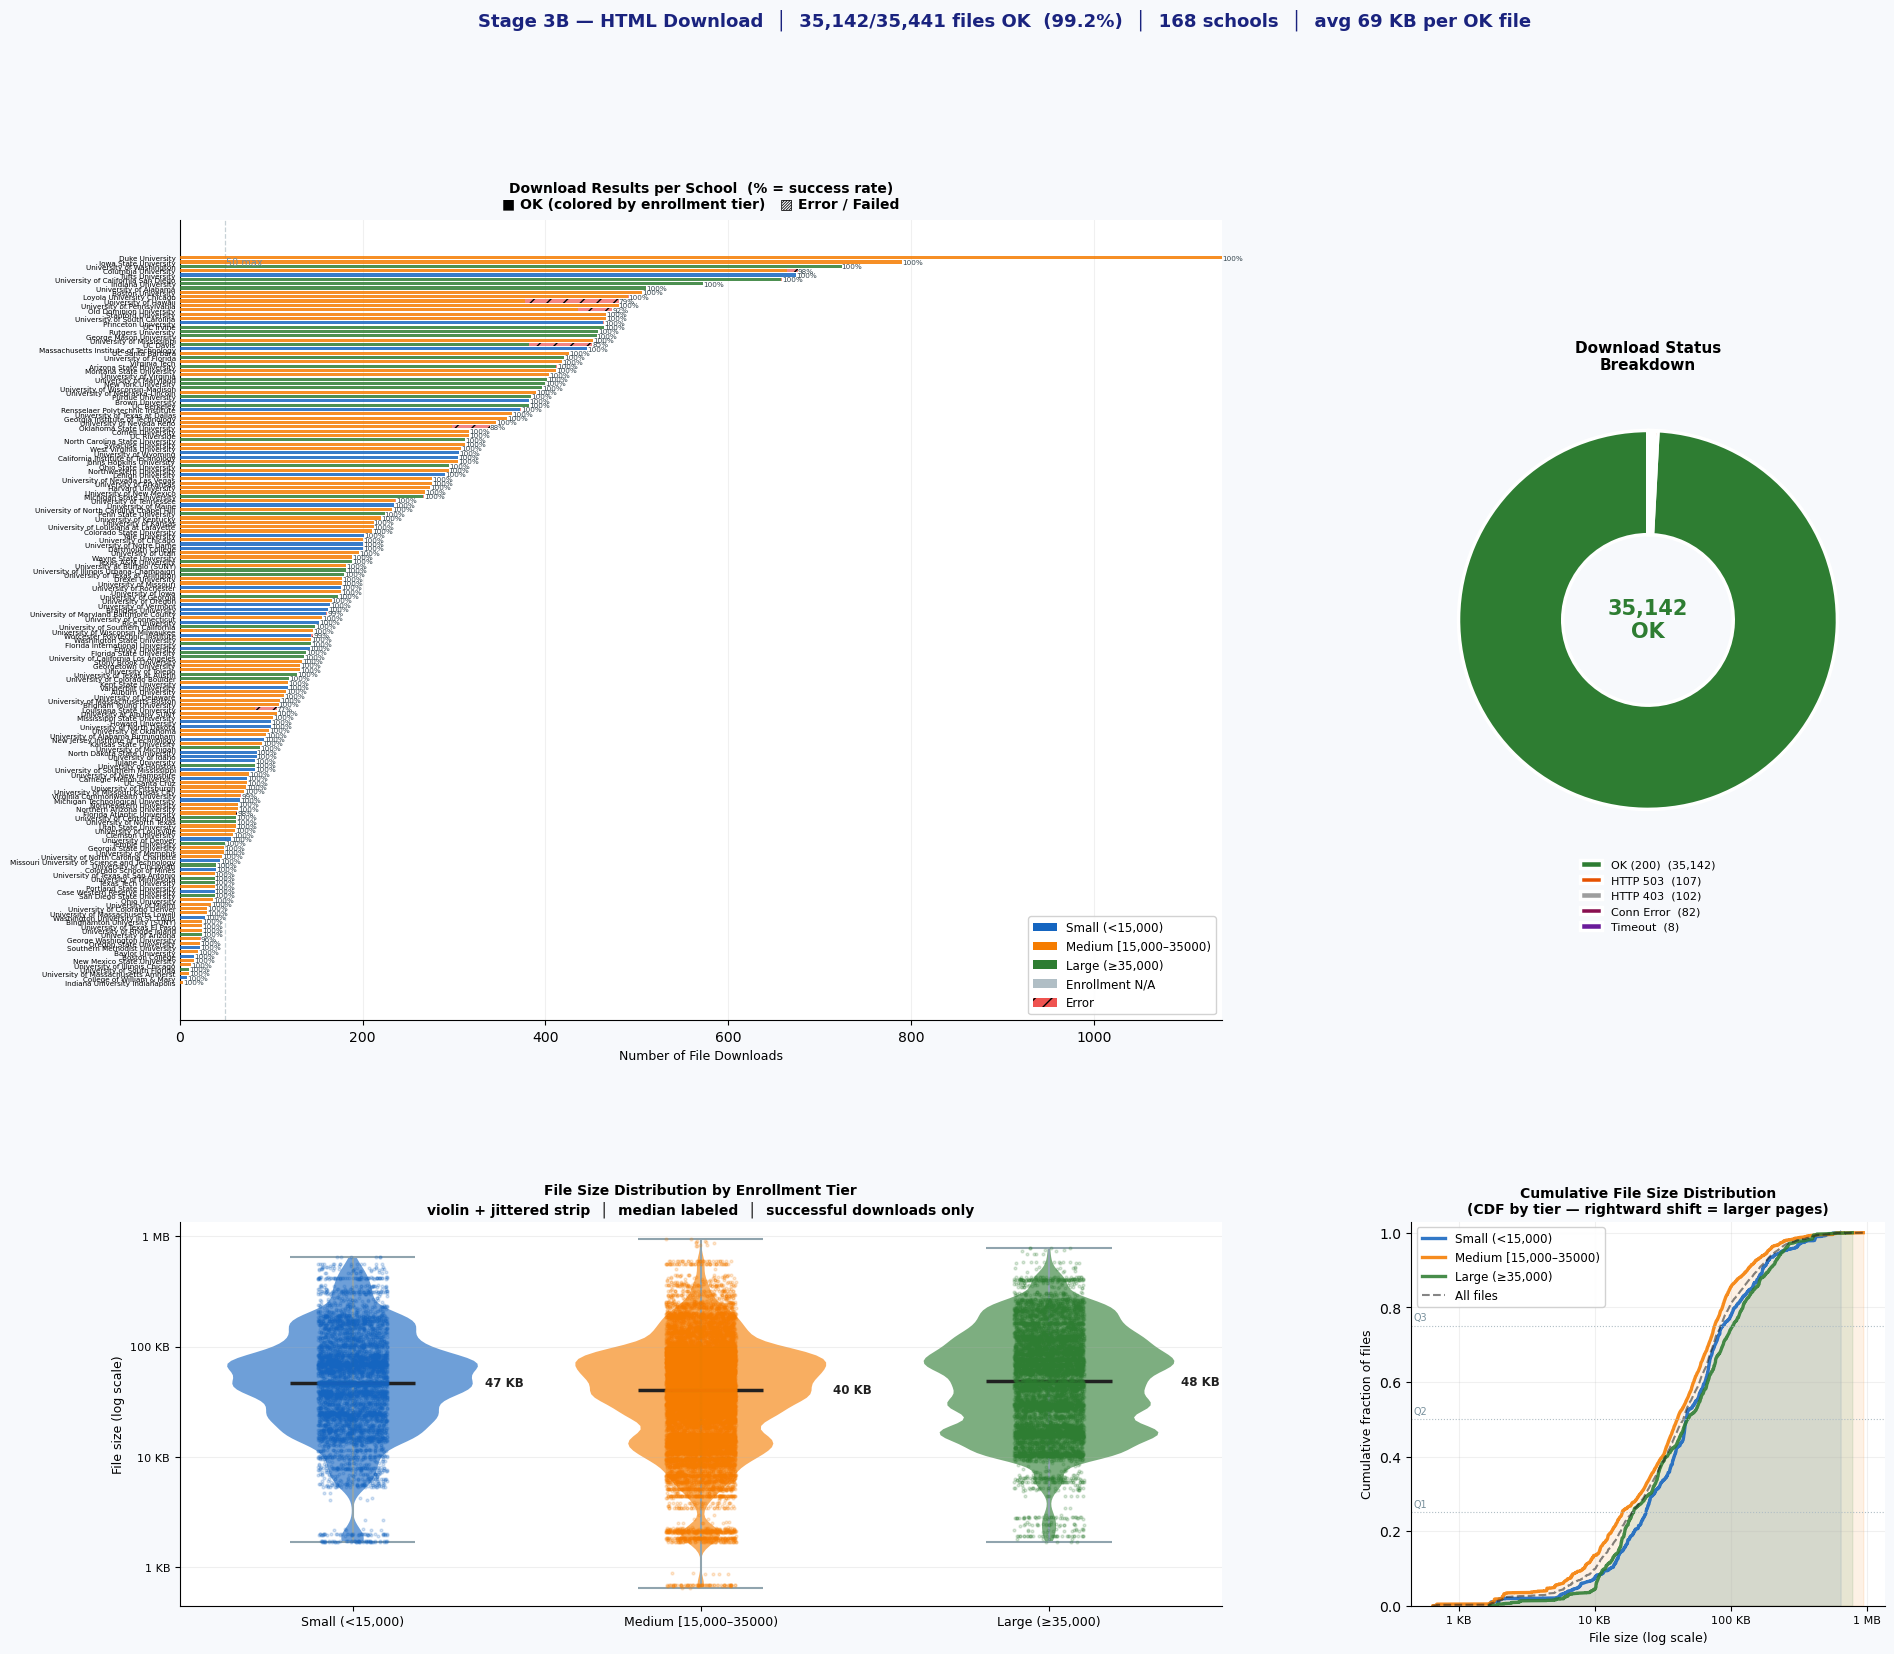

  Saved → /sfs/gpfs/tardis/home/dzk3ja/Ivy_Net/tenure/tenure_pipeline/stage3b_summary.png


In [10]:
# === CELL 3B-VIZ: HTML DOWNLOAD — SUMMARY VISUALIZATION ===
# Plotting logic lives in tenure_pipeline/viz_pipeline.py — edit there.
import json as _json
reload_py_files()
import viz_pipeline

# Load index_records from disk if Cell 3B hasn't been run this session
if 'index_records' not in dir() or not index_records:
    with open(STAGE3_INDEX, encoding='utf-8') as _f:
        index_records = [_json.loads(line) for line in _f if line.strip()]
    print(f"  Loaded {len(index_records):,} index records from disk.")

VIZ_SCHOOL_SORT = 'volume'  # 'alphabetical' — A→Z on per-school download bar chart

viz_pipeline.plot_stage3b(
    index_records = index_records,
    df_schools    = df_schools,
    out_path      = TENURE_PIPELINE_DIR / 'stage3b_summary.png',
    index_path    = STAGE3_INDEX,
    school_sort   = VIZ_SCHOOL_SORT,
    enrollment_path = STAGE3_ENROLLMENT,
    cdx_year_min  = CDX_YEAR_MIN,
    cdx_year_max  = CDX_YEAR_MAX,
)

## 🔬 CELL 3C: STAGE 3C — Sub-Page Rescue (Cornell & UMD)

### The Problem

Cornell and UMD both serve their `/people` hub page as a JavaScript-rendered shell.
The Wayback Machine captured the HTML skeleton but not the JS-loaded faculty content,
leaving us with 54 empty files.

### The Solution

By parsing the nav bar links in our existing (empty) Cornell and UMD HTML files, we
discovered that **every single archived parent page** contains a direct Wayback link
to a faculty-specific sub-page that **is** fully static HTML:

| School | URL Pattern | Type |
|--------|-------------|------|
| Cornell (2005–2012) | `/People/faculty/index.htm` | Static `.htm` file |
| Cornell (2013–2024) | `/people/faculty` | Static sub-page (different render path from hub) |
| UMD (2013–2024) | `/people/phonebook/faculty` | Dept. Phonebook — plain HTML list |

All tested pages returned **60–316 KB of rich content** with 67–128 professor mentions
each. No CDX queries needed — the exact Wayback timestamps are already embedded
in the nav bars we downloaded.

### Output

- Overwrites the empty `YYYY_season.html` files in `faculty_snapshots/cornell_university/`
  and `faculty_snapshots/university_of_maryland/` with actual faculty data.
- Appends download records to `faculty_subpage_index.jsonl` for checkpoint/resume.

In [17]:
# === CELL 3C: STAGE 3C — SUB-PAGE RESCUE (Cornell & UMD) ===
#
# Two-pass deferred-pile strategy:
#   Pass 1  — try all pending URLs at normal CDX_DELAY pace
#               ok            → written to index immediately
#               404           → written as http_404 (write-off, never retried)
#               other HTTP    → written as http_error (retried on next run)
#               conn error    → held silently in deferred pile (nothing written yet)
#               429 exhausted → also held in deferred pile
#   Cooldown — CDX_DEFERRED_WAIT second countdown if any deferred entries exist
#   Pass 2  — retry deferred pile at CDX_DEFERRED_DELAY pace
#               ok            → written to index
#               still failing → written as connection_error (retried on next run)

import json as _json_3c

def _fetch_one(url, headers, timeout=30):
    """Single GET attempt. Returns (http_status_int, response_or_None, error_str_or_None).
    Returns status=-1 on connection/timeout errors."""
    try:
        resp = requests.get(url, headers=headers, timeout=timeout)
        return resp.status_code, resp, None
    except Exception as e:
        return -1, None, str(e)


def download_subpages(
        targets_path   = STAGE3C_TARGETS,
        index_path     = STAGE3C_INDEX,
        html_dir       = STAGE3_HTML_DIR,
        delay          = CDX_DELAY,
        deferred_wait  = CDX_DEFERRED_WAIT,
        deferred_delay = CDX_DEFERRED_DELAY,
        headers        = CDX_HEADERS,
):
    """Download faculty sub-pages for Cornell & UMD.
    Connection errors are deferred to a second pass after a cooling-down wait."""
    import time

    targets = _json_3c.loads(targets_path.read_text())

    # Checkpoint — only 'ok' entries are considered done; all others are retried
    done = set()
    if index_path.exists():
        for line in index_path.open():
            rec = _json_3c.loads(line)
            if rec.get('subpage_status') == 'ok':
                done.add((rec['uni_slug'], rec['year'], rec['season']))

    pending = [t for t in targets
               if (t['uni_slug'], t['year'], t['season']) not in done]

    if not pending:
        print(f"All {len(targets)} sub-pages already downloaded. Nothing to do.")
        return

    print(f"  {len(done)} already done  |  {len(pending)} remaining of {len(targets)} total")
    t0 = time_start(f"Cell 3C: {len(pending)} sub-pages — 2-pass deferred strategy")

    index_fh = index_path.open('a')
    counts   = {'ok': 0, 'http_404': 0, 'http_error': 0, 'conn_error': 0}
    deferred = []   # targets that hit connection errors in pass 1

    # ── PASS 1 ──────────────────────────────────────────────────────────────
    print(f"\n  ▶ PASS 1 — {len(pending)} URLs  (delay={delay}s per request)")

    with tqdm(pending, desc='Pass 1', unit='file') as pbar:
        for t in pbar:
            uni_slug   = t['uni_slug']
            year, ssn  = t['year'], t['season']
            url        = t['sub_page_url']
            local_path = html_dir / uni_slug / f'{year}_{ssn}.html'
            local_path.parent.mkdir(parents=True, exist_ok=True)

            pbar.set_postfix(school=uni_slug.split('_')[0], yr=year, ssn=ssn)
            status, resp, err = _fetch_one(url, headers)

            if status == 200:
                local_path.write_bytes(resp.content)
                rec = dict(t, status=200, nbytes=len(resp.content),
                           subpage_status='ok', pass_num=1)
                index_fh.write(_json_3c.dumps(rec) + '\n'); index_fh.flush()
                counts['ok'] += 1

            elif status == 404:
                rec = dict(t, status=404, nbytes=0,
                           subpage_status='http_404', pass_num=1)
                index_fh.write(_json_3c.dumps(rec) + '\n'); index_fh.flush()
                counts['http_404'] += 1
                tqdm.write(f'  404 write-off: {year}_{ssn} {uni_slug}')

            elif status == 429:
                # One immediate back-off, then defer if still failing
                tqdm.write(f'  429 — quick back-off 15s then defer: {year}_{ssn} {uni_slug}')
                time.sleep(15)
                status2, resp2, err2 = _fetch_one(url, headers)
                if status2 == 200:
                    local_path.write_bytes(resp2.content)
                    rec = dict(t, status=200, nbytes=len(resp2.content),
                               subpage_status='ok', pass_num=1)
                    index_fh.write(_json_3c.dumps(rec) + '\n'); index_fh.flush()
                    counts['ok'] += 1
                else:
                    deferred.append(t)
                    tqdm.write(f'  429 still failing — deferred: {year}_{ssn} {uni_slug}')

            elif status == -1:
                # Connection / timeout error — defer without writing to index
                deferred.append(t)
                tqdm.write(f'  Conn error — deferred: {year}_{ssn} {uni_slug}')

            else:
                # Other HTTP error (500, 503, etc.) — log and let next run retry
                rec = dict(t, status=status, nbytes=0,
                           subpage_status='http_error', pass_num=1,
                           error=err or f'HTTP {status}')
                index_fh.write(_json_3c.dumps(rec) + '\n'); index_fh.flush()
                counts['http_error'] += 1
                tqdm.write(f'  HTTP {status}: {year}_{ssn} {uni_slug}')

            time.sleep(delay)

    tqdm.write(
        f'\n  Pass 1 done: {counts["ok"]} ok | {counts["http_404"]} 404s | '
        f'{counts["http_error"]} http_err | {len(deferred)} deferred'
    )

    # ── COOLING-DOWN WAIT + PASS 2 ───────────────────────────────────────────
    if deferred:
        print(f'\n  ⏳ {len(deferred)} deferred — cooling down for {deferred_wait}s '
              f'before pass 2 (delay={deferred_delay}s)...')
        for _ in tqdm(range(deferred_wait), desc='Cooldown', unit='s', leave=False):
            time.sleep(1)

        print(f'\n  ▶ PASS 2 — {len(deferred)} deferred URLs  (delay={deferred_delay}s per request)')

        with tqdm(deferred, desc='Pass 2', unit='file') as pbar:
            for t in pbar:
                uni_slug   = t['uni_slug']
                year, ssn  = t['year'], t['season']
                url        = t['sub_page_url']
                local_path = html_dir / uni_slug / f'{year}_{ssn}.html'

                pbar.set_postfix(school=uni_slug.split('_')[0], yr=year, ssn=ssn)
                status, resp, err = _fetch_one(url, headers)

                if status == 200:
                    local_path.write_bytes(resp.content)
                    rec = dict(t, status=200, nbytes=len(resp.content),
                               subpage_status='ok', pass_num=2)
                    counts['ok'] += 1
                else:
                    rec = dict(t, status=status, nbytes=0,
                               subpage_status='connection_error', pass_num=2,
                               error=err or f'HTTP {status}')
                    counts['conn_error'] += 1
                    tqdm.write(f'  Still failing — connection_error: {year}_{ssn} {uni_slug}')

                index_fh.write(_json_3c.dumps(rec) + '\n'); index_fh.flush()
                time.sleep(deferred_delay)

        tqdm.write(f'\n  Pass 2 done: {counts["ok"]} total ok | {counts["conn_error"]} conn_err')
    else:
        print('  ✓ No deferred URLs — pass 2 skipped.')

    index_fh.close()
    time_stop(
        t0,
        f"Cell 3C: {counts['ok']} ok | {counts['http_404']} write-offs "
        f"| {counts['http_error']} http_err | {counts['conn_error']} conn_err (retry next run)"
    )


if RUN_CELL3C:
    download_subpages()
else:
    if STAGE3C_INDEX.exists():
        idx  = [_json_3c.loads(l) for l in STAGE3C_INDEX.open()]
        ok   = sum(1 for r in idx if r.get('subpage_status') == 'ok')
        w404 = sum(1 for r in idx if r.get('subpage_status') == 'http_404')
        cerr = sum(1 for r in idx if r.get('subpage_status') == 'connection_error')
        herr = sum(1 for r in idx if r.get('subpage_status') == 'http_error')
        print(f"RUN_CELL3C=False — sub-page index loaded from disk")
        print(f"  {ok} ok | {w404} write-offs (404) | {cerr} conn_err | {herr} http_err | {len(idx)} total")
    else:
        print("RUN_CELL3C=False — index not yet on disk (run Cell 3C first)")

RUN_CELL3C=False — index not yet on disk (run Cell 3C first)


## 🔬 CELL 3D: STAGE 3D — Sub-Page Rescue (UIUC & UW-Madison)

### The Problem
Two schools captured the wrong content in Cells 3A/3B:

- **UIUC**: The primary faculty directory page was a JavaScript hub — Wayback captured blank shells. Nav bars of those shells link to *static* sub-pages:
  - 2000–2017 (on `cs.uiuc.edu`): `/people/faculty/department-faculty`
  - 2022–2024 (on `cs.illinois.edu`): `/about/people/all-faculty`
  - Years in between were captured from an awards/chairs page with no faculty list.

- **UW-Madison**: CDX discovery found `cs.wisc.edu/people/pb` (Paul Barford's personal bio page) rather than the faculty directory. The nav bars of those files all link to `cs.wisc.edu/people/faculty`.

### The Solution
Cell 3D is a two-step process:

1. **`build_d_targets()`** — reads every existing UIUC and UW-Madison HTML file, parses its nav bar with `lxml`, extracts the correct faculty-list URL, and writes `faculty_subpage_d_targets.json`.
2. **`download_d_subpages()`** — downloads each target URL, *overwriting* the wrong existing file. Same two-pass deferred strategy as Cell 3C.

### Output
- `tenure_pipeline/faculty_subpage_d_targets.json` — extraction targets
- `tenure_pipeline/faculty_subpage_d_index.jsonl` — download log
- Overwrites: `faculty_snapshots/university_of_illinois_urbana_champaign/YYYY_season.html`
- Overwrites: `faculty_snapshots/university_of_wisconsin_madison/YYYY_season.html`

In [18]:
# === CELL 3D: STAGE 3D — SUB-PAGE RESCUE (UIUC & UW-Madison) ===
#
# Two-step process:
#   Step 1 — build_d_targets(): scan existing HTML files, extract correct
#             faculty-list URLs from each nav bar → faculty_subpage_d_targets.json
#   Step 2 — download_d_subpages(): download the correct sub-pages and overwrite
#             existing (wrong-content) HTML files.
#
# Two-pass deferred-pile strategy (same as Cell 3C):
#   Pass 1  — try all pending URLs at CDX_DELAY pace
#               ok            → written to index; file overwritten on disk
#               404           → written as http_404 (write-off, never retried)
#               other HTTP    → written as http_error (retried on next run)
#               conn error    → held silently in deferred pile
#               429 exhausted → also held in deferred pile
#   Cooldown — CDX_DEFERRED_WAIT second countdown if any deferred entries exist
#   Pass 2  — retry deferred pile at CDX_DEFERRED_DELAY pace
#               ok            → written to index; file overwritten on disk
#               still failing → written as connection_error (retried on next run)
#
# Depends on _fetch_one() defined in Cell 3C (available when cells run in order).

import json as _json_3d
from lxml import etree as _etree_3d

# ── Which schools to rescue and how to recognise faculty-list hrefs ──────────
_D_RESCUE_SCHOOLS = {
    'university_of_illinois_urbana_champaign': {
        'href_patterns': ['department-faculty', 'all-faculty'],
        'href_excludes': ['award', 'chair'],          # skip awards/chairs pages
    },
    'university_of_wisconsin_madison': {
        'href_patterns': ['/people/faculty'],
        'href_excludes': ['/affiliate', '/pb', '/emeritus', '/staff'],
    },
}


def _extract_faculty_href_lxml(html_bytes, href_patterns, href_excludes=None):
    """
    Parse html_bytes with lxml's HTML parser. Return the first <a href=...> whose
    href contains any string in href_patterns and none in href_excludes, or None.
    """
    href_excludes = href_excludes or []
    try:
        parser = _etree_3d.HTMLParser(recover=True)
        tree   = _etree_3d.fromstring(html_bytes, parser)
    except Exception:
        return None

    for a in tree.iter('a'):
        href = (a.get('href') or '').strip()
        if not href:
            continue
        if any(p in href for p in href_patterns):
            if any(x in href for x in href_excludes):
                continue
            return href
    return None


def _href_to_wayback_url(href, timestamp):
    """
    Convert a nav-bar href from a Wayback-served page to a full Wayback request URL.
      /web/TS/http://...  → https://web.archive.org/web/TS/http://...
      http://...           → https://web.archive.org/web/{timestamp}/{href}
    """
    if href.startswith('/web/'):
        return f'https://web.archive.org{href}'
    elif href.startswith('http'):
        return f'https://web.archive.org/web/{timestamp}/{href}'
    return None


def build_d_targets(
        html_dir     = STAGE3_HTML_DIR,
        plan_path    = STAGE3_PLAN,
        targets_path = STAGE3D_TARGETS,
):
    """
    Scan rescue-school HTML files, extract faculty sub-page URLs from nav bars,
    and write faculty_subpage_d_targets.json.
    """
    import time as _time

    # Load plan for timestamps (year+season → timestamp)
    plan_by_key = {}
    if plan_path.exists():
        for line in plan_path.open():
            r = _json_3d.loads(line)
            key = (r['uni_slug'], str(r['year']), r['season'])
            plan_by_key[key] = r

    targets = []

    for uni_slug, cfg in _D_RESCUE_SCHOOLS.items():
        uni_dir = html_dir / uni_slug
        if not uni_dir.exists():
            print(f"  WARNING: no directory for {uni_slug} — skipping")
            continue

        html_files = sorted(uni_dir.glob('*.html'))
        found, missing = 0, 0

        for hf in html_files:
            stem  = hf.stem                   # e.g. '2016_fall'
            parts = stem.split('_', 1)
            if len(parts) != 2:
                continue
            year, season = parts[0], parts[1]

            # Get timestamp from plan; fall back to a reasonable default
            plan_rec  = plan_by_key.get((uni_slug, year, season))
            timestamp = plan_rec['timestamp'] if plan_rec else f'{year}1015000000'

            try:
                html_bytes = hf.read_bytes()
            except Exception as e:
                print(f"  Read error {uni_slug}/{stem}: {e}")
                missing += 1
                continue

            href = _extract_faculty_href_lxml(
                html_bytes,
                cfg['href_patterns'],
                cfg.get('href_excludes'),
            )

            if href:
                wayback_url = _href_to_wayback_url(href, timestamp)
                if wayback_url:
                    targets.append({
                        'uni_slug'    : uni_slug,
                        'year'        : int(year),
                        'season'      : season,
                        'timestamp'   : timestamp,
                        'sub_page_url': wayback_url,
                    })
                    found += 1
                else:
                    print(f"  Unresolvable href {href!r} — {uni_slug}/{stem}")
                    missing += 1
            else:
                print(f"  No faculty link found — {uni_slug}/{stem}")
                missing += 1

        print(f"  {uni_slug}: {found} targets, {missing} no-link")

    targets_path.parent.mkdir(parents=True, exist_ok=True)
    targets_path.write_text(_json_3d.dumps(targets, indent=2))
    print(f"\n  Targets written: {len(targets)} total → {targets_path.resolve()}")
    return targets


def download_d_subpages(
        targets_path   = STAGE3D_TARGETS,
        index_path     = STAGE3D_INDEX,
        html_dir       = STAGE3_HTML_DIR,
        delay          = CDX_DELAY,
        deferred_wait  = CDX_DEFERRED_WAIT,
        deferred_delay = CDX_DEFERRED_DELAY,
        headers        = CDX_HEADERS,
):
    """Download rescued faculty sub-pages for UIUC and UW-Madison.
    Overwrites existing (wrong-content) HTML files. Two-pass deferred strategy."""
    import time

    targets = _json_3d.loads(targets_path.read_text())

    # Checkpoint — only 'ok' entries are considered done; all others are retried
    done = set()
    if index_path.exists():
        for line in index_path.open():
            rec = _json_3d.loads(line)
            if rec.get('subpage_status') == 'ok':
                done.add((rec['uni_slug'], rec['year'], rec['season']))

    pending = [t for t in targets
               if (t['uni_slug'], t['year'], t['season']) not in done]

    if not pending:
        print(f"All {len(targets)} sub-pages already downloaded. Nothing to do.")
        return

    print(f"  {len(done)} already done  |  {len(pending)} remaining of {len(targets)} total")
    t0 = time_start(f"Cell 3D: {len(pending)} sub-pages — 2-pass deferred strategy")

    index_fh = index_path.open('a')
    counts   = {'ok': 0, 'http_404': 0, 'http_error': 0, 'conn_error': 0}
    deferred = []

    # ── PASS 1 ───────────────────────────────────────────────────────────────
    print(f"\n  ▶ PASS 1 — {len(pending)} URLs  (delay={delay}s per request)")

    with tqdm(pending, desc='Pass 1', unit='file') as pbar:
        for t in pbar:
            uni_slug   = t['uni_slug']
            year, ssn  = t['year'], t['season']
            url        = t['sub_page_url']
            local_path = html_dir / uni_slug / f'{year}_{ssn}.html'
            local_path.parent.mkdir(parents=True, exist_ok=True)

            pbar.set_postfix(school=uni_slug.split('_')[0], yr=year, ssn=ssn)
            status, resp, err = _fetch_one(url, headers)

            if status == 200:
                local_path.write_bytes(resp.content)
                rec = dict(t, status=200, nbytes=len(resp.content),
                           subpage_status='ok', pass_num=1)
                index_fh.write(_json_3d.dumps(rec) + '\n'); index_fh.flush()
                counts['ok'] += 1

            elif status == 404:
                rec = dict(t, status=404, nbytes=0,
                           subpage_status='http_404', pass_num=1)
                index_fh.write(_json_3d.dumps(rec) + '\n'); index_fh.flush()
                counts['http_404'] += 1
                tqdm.write(f'  404 write-off: {year}_{ssn} {uni_slug}')

            elif status == 429:
                tqdm.write(f'  429 — quick back-off 15s then defer: {year}_{ssn} {uni_slug}')
                time.sleep(15)
                status2, resp2, err2 = _fetch_one(url, headers)
                if status2 == 200:
                    local_path.write_bytes(resp2.content)
                    rec = dict(t, status=200, nbytes=len(resp2.content),
                               subpage_status='ok', pass_num=1)
                    index_fh.write(_json_3d.dumps(rec) + '\n'); index_fh.flush()
                    counts['ok'] += 1
                else:
                    deferred.append(t)
                    tqdm.write(f'  429 still failing — deferred: {year}_{ssn} {uni_slug}')

            elif status == -1:
                deferred.append(t)
                tqdm.write(f'  Conn error — deferred: {year}_{ssn} {uni_slug}')

            else:
                rec = dict(t, status=status, nbytes=0,
                           subpage_status='http_error', pass_num=1,
                           error=err or f'HTTP {status}')
                index_fh.write(_json_3d.dumps(rec) + '\n'); index_fh.flush()
                counts['http_error'] += 1
                tqdm.write(f'  HTTP {status}: {year}_{ssn} {uni_slug}')

            time.sleep(delay)

    tqdm.write(
        f'\n  Pass 1 done: {counts["ok"]} ok | {counts["http_404"]} 404s | '
        f'{counts["http_error"]} http_err | {len(deferred)} deferred'
    )

    # ── COOLING-DOWN WAIT + PASS 2 ───────────────────────────────────────────
    if deferred:
        print(f'\n  ⏳ {len(deferred)} deferred — cooling down {deferred_wait}s '
              f'before pass 2 (delay={deferred_delay}s)...')
        for _ in tqdm(range(deferred_wait), desc='Cooldown', unit='s', leave=False):
            time.sleep(1)

        print(f'\n  ▶ PASS 2 — {len(deferred)} deferred URLs  (delay={deferred_delay}s per request)')

        with tqdm(deferred, desc='Pass 2', unit='file') as pbar:
            for t in pbar:
                uni_slug   = t['uni_slug']
                year, ssn  = t['year'], t['season']
                url        = t['sub_page_url']
                local_path = html_dir / uni_slug / f'{year}_{ssn}.html'

                pbar.set_postfix(school=uni_slug.split('_')[0], yr=year, ssn=ssn)
                status, resp, err = _fetch_one(url, headers)

                if status == 200:
                    local_path.write_bytes(resp.content)
                    rec = dict(t, status=200, nbytes=len(resp.content),
                               subpage_status='ok', pass_num=2)
                    counts['ok'] += 1
                else:
                    rec = dict(t, status=status, nbytes=0,
                               subpage_status='connection_error', pass_num=2,
                               error=err or f'HTTP {status}')
                    counts['conn_error'] += 1
                    tqdm.write(f'  Still failing — connection_error: {year}_{ssn} {uni_slug}')

                index_fh.write(_json_3d.dumps(rec) + '\n'); index_fh.flush()
                time.sleep(deferred_delay)

        tqdm.write(f'\n  Pass 2 done: {counts["ok"]} total ok | {counts["conn_error"]} conn_err')
    else:
        print('  ✓ No deferred URLs — pass 2 skipped.')

    index_fh.close()
    time_stop(
        t0,
        f"Cell 3D: {counts['ok']} ok | {counts['http_404']} write-offs "
        f"| {counts['http_error']} http_err | {counts['conn_error']} conn_err (retry next run)"
    )


if RUN_CELL3D:
    print("  Step 1: extracting faculty sub-page URLs from existing HTML nav bars...")
    build_d_targets()
    print("\n  Step 2: downloading rescued sub-pages...")
    download_d_subpages()
else:
    if STAGE3D_INDEX.exists():
        idx  = [_json_3d.loads(l) for l in STAGE3D_INDEX.open()]
        ok   = sum(1 for r in idx if r.get('subpage_status') == 'ok')
        w404 = sum(1 for r in idx if r.get('subpage_status') == 'http_404')
        cerr = sum(1 for r in idx if r.get('subpage_status') == 'connection_error')
        herr = sum(1 for r in idx if r.get('subpage_status') == 'http_error')
        print(f"RUN_CELL3D=False — sub-page D index loaded from disk")
        print(f"  {ok} ok | {w404} write-offs (404) | {cerr} conn_err | {herr} http_err | {len(idx)} total")
    else:
        print("RUN_CELL3D=False — index not yet on disk (run Cell 3D first)")

RUN_CELL3D=False — index not yet on disk (run Cell 3D first)


## 🔬 CELL 3E: STAGE 3E — Redirect Rescue (NC State)

### The Problem
NC State's primary CDX URL (`www.csc.ncsu.edu/faculty/`) redirected even in 2007 to `/directories/faculty.php`. Wayback faithfully captured the redirect shell — a 2.1 KB `<meta http-equiv="refresh">` page — not the actual faculty directory. All 16 downloaded files are identical ~2.1 KB shells with zero useful content.

### The Solution (Simpler than 3C/3D)
No CDX query or nav-bar parsing needed. The correct timestamped Wayback URL is already embedded in each redirect shell:

```html
<meta http-equiv="refresh" content="0;url=https://web.archive.org/web/20070919194824/http://www.csc.ncsu.edu/directories/faculty.php">
```

Cell 3E reads each NC State HTML file, extracts the redirect target URL via regex, and downloads the `/directories/faculty.php` page for that exact Wayback timestamp — overwriting the shell with real content.

### Output
- **Overwritten files**: `tenure_pipeline/faculty_snapshots/north_carolina_state_university/YYYY_season.html`
- **Index**: `tenure_pipeline/faculty_subpage_e_index.jsonl`

In [19]:
# === CELL 3E: STAGE 3E — REDIRECT RESCUE (NC STATE) ===
#
# NC State's Wayback snapshots are meta-refresh redirect shells pointing to
# http://www.csc.ncsu.edu/directories/faculty.php with the Wayback timestamp embedded.
# All 16 downloaded files are ~2.1 KB shells — zero useful content.
#
# Two-step process:
#   Step 1 — build_e_targets(): read each NC State HTML file, extract the redirect
#             target URL via regex → in-memory list (no CDX or nav-bar parsing needed)
#   Step 2 — download_e_subpages(): download the correct /directories/faculty.php page
#             for each timestamp and overwrite the shell file.
#
# Two-pass deferred-pile strategy (same as Cells 3C and 3D):
#   Pass 1  — try all pending at CDX_DELAY pace
#               ok            → overwrite file; write to index
#               404           → write-off (never retried)
#               other HTTP    → log as http_error (retried next run)
#               conn error    → defer silently
#   Cooldown — CDX_DEFERRED_WAIT seconds if any deferred exist
#   Pass 2  — retry deferred at CDX_DEFERRED_DELAY pace
#               ok            → overwrite file; write to index
#               still failing → log as connection_error (retried next run)
#
# Depends on _fetch_one() defined in Cell 3C (available when cells run in order).

import re   as _re_3e
import json as _json_3e

_E_SLUG       = 'north_carolina_state_university'
_E_REFRESH_RE = _re_3e.compile(r'content=["\']0;url=([^"\']+)["\']', _re_3e.IGNORECASE)


def build_e_targets():
    """Read NC State HTML redirect shells, extract the embedded Wayback redirect URLs."""
    html_dir = STAGE3_HTML_DIR / _E_SLUG
    targets  = []

    for html_file in sorted(html_dir.glob('*.html')):
        year_str, season = html_file.stem.split('_')
        html = html_file.read_text(encoding='utf-8', errors='ignore')

        m = _E_REFRESH_RE.search(html)
        if m:
            redirect_url = m.group(1).strip()
            targets.append({
                'university' : 'North Carolina State University',
                'uni_slug'   : _E_SLUG,
                'year'       : int(year_str),
                'season'     : season,
                'wayback_url': redirect_url,
                'local_path' : disk_html_to_plan_local_path(html_file),
            })
            print(f"  {html_file.stem}  →  {redirect_url}")
        else:
            print(f"  {html_file.stem}  → no redirect found (already rescued or unexpected content)")

    print(f"\n  {len(targets)} redirect targets from {len(list(html_dir.glob('*.html')))} files")
    return targets


def download_e_subpages(targets):
    """Two-pass deferred download: fetch redirect targets and overwrite shell files."""
    # Checkpoint — only 'ok' entries are considered done; all others are retried
    done_keys = set()
    if STAGE3E_INDEX.exists():
        for line in STAGE3E_INDEX.open():
            rec = _json_3e.loads(line)
            if rec.get('subpage_status') == 'ok':
                done_keys.add(f"{rec['uni_slug']}_{rec['year']}_{rec['season']}")

    pending = [t for t in targets
               if f"{t['uni_slug']}_{t['year']}_{t['season']}" not in done_keys]

    if not pending:
        print("  All NC State redirects already rescued — nothing to do.")
        return

    print(f"  {len(done_keys)} already rescued | {len(pending)} to download\n")

    session = requests.Session()
    session.headers.update(CDX_HEADERS)

    deferred = []
    ok_n = n404 = herr = 0

    # ── PASS 1 ───────────────────────────────────────────────────────────────
    for t in tqdm(pending, desc="Pass 1 (NC State redirects)", unit="file",
                  bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]'):
        slug, yr, ssn = t['uni_slug'], t['year'], t['season']
        url   = t['wayback_url']
        local = resolve_faculty_snapshot_path(t['local_path'])

        status, html, http_code = _fetch_one(session, url)

        if status == 'ok':
            local.write_bytes(html.encode('utf-8', errors='replace'))
            with open(STAGE3E_INDEX, 'a') as _f:
                _f.write(_json_3e.dumps({
                    'uni_slug': slug, 'year': yr, 'season': ssn,
                    'wayback_url': url, 'subpage_status': 'ok',
                    'file_size_bytes': len(html),
                }) + '\n')
            ok_n += 1
            tqdm.write(f"  ok: {yr}_{ssn}  ({len(html):,} bytes)")

        elif status == 'http_404':
            with open(STAGE3E_INDEX, 'a') as _f:
                _f.write(_json_3e.dumps({
                    'uni_slug': slug, 'year': yr, 'season': ssn,
                    'wayback_url': url, 'subpage_status': 'http_404',
                    'file_size_bytes': 0,
                }) + '\n')
            n404 += 1
            tqdm.write(f"  404 write-off: {yr}_{ssn}")

        elif status == 'http_error':
            with open(STAGE3E_INDEX, 'a') as _f:
                _f.write(_json_3e.dumps({
                    'uni_slug': slug, 'year': yr, 'season': ssn,
                    'wayback_url': url, 'subpage_status': 'http_error',
                    'http_code': http_code, 'file_size_bytes': 0,
                }) + '\n')
            herr += 1

        else:  # connection_error
            deferred.append(t)

        time.sleep(CDX_DELAY)

    print(f"\n  Pass 1 done: {ok_n} ok | {n404} 404s | {herr} http_err | {len(deferred)} deferred")

    # ── COOLING-DOWN WAIT + PASS 2 ────────────────────────────────────────────
    if deferred:
        print(f"\n  Cooling down {CDX_DEFERRED_WAIT}s before pass 2...")
        for _ in tqdm(range(CDX_DEFERRED_WAIT, 0, -1), desc="Cooldown", unit="s", leave=False):
            time.sleep(1)

        cerr = 0
        for t in tqdm(deferred, desc="Pass 2 (deferred)", unit="file"):
            slug, yr, ssn = t['uni_slug'], t['year'], t['season']
            url   = t['wayback_url']
            local = resolve_faculty_snapshot_path(t['local_path'])

            status, html, http_code = _fetch_one(session, url)

            if status == 'ok':
                local.write_bytes(html.encode('utf-8', errors='replace'))
                with open(STAGE3E_INDEX, 'a') as _f:
                    _f.write(_json_3e.dumps({
                        'uni_slug': slug, 'year': yr, 'season': ssn,
                        'wayback_url': url, 'subpage_status': 'ok',
                        'file_size_bytes': len(html),
                    }) + '\n')
                ok_n += 1
                tqdm.write(f"  ok (pass2): {yr}_{ssn}  ({len(html):,} bytes)")
            else:
                final_status = 'connection_error' if status == 'connection_error' else 'http_error'
                with open(STAGE3E_INDEX, 'a') as _f:
                    _f.write(_json_3e.dumps({
                        'uni_slug': slug, 'year': yr, 'season': ssn,
                        'wayback_url': url, 'subpage_status': final_status,
                        'file_size_bytes': 0,
                    }) + '\n')
                cerr += 1
            time.sleep(CDX_DEFERRED_DELAY)

        print(f"  Pass 2 done: {ok_n} total ok | {cerr} still failing")
    else:
        print("  ✓ No deferred URLs — pass 2 skipped.")


if RUN_CELL3E:
    clk = time_start("Cell 3E — NC State Redirect Rescue")
    print("  Step 1: extracting redirect URLs from existing HTML files...")
    e_targets = build_e_targets()
    print("\n  Step 2: downloading rescued pages...")
    download_e_subpages(e_targets)
    time_stop(clk)
else:
    if STAGE3E_INDEX.exists():
        idx_e = [_json_3e.loads(l) for l in STAGE3E_INDEX.open()]
        ok_e  = sum(1 for r in idx_e if r.get('subpage_status') == 'ok')
        w404  = sum(1 for r in idx_e if r.get('subpage_status') == 'http_404')
        cerr  = sum(1 for r in idx_e if r.get('subpage_status') == 'connection_error')
        herr  = sum(1 for r in idx_e if r.get('subpage_status') == 'http_error')
        print(f"RUN_CELL3E=False — index loaded from disk")
        print(f"  {ok_e} ok | {w404} write-offs (404) | {cerr} conn_err | {herr} http_err | {len(idx_e)} total")
    else:
        print("RUN_CELL3E=False — index not yet on disk (run Cell 3E first)")

RUN_CELL3E=False — index not yet on disk (run Cell 3E first)


# 🔍 CELL 4: STAGE 4 — HTML FACULTY PARSE

### Purpose
Parse every downloaded HTML snapshot to extract faculty **name** and **rank** (assistant / associate / full / emeritus / other).

### Input
`tenure_pipeline/faculty_snapshots/<uni_slug>/YYYY_season.html`

### Output
`tenure_pipeline/faculty_snapshots_parsed.jsonl` — one record per **(school × snapshot × faculty member)**

### Parser
Logic lives in `tenure_pipeline/html_parser.py`.  Four strategies tried in parallel; whichever yields the most unique faculty records wins:
1. **Drupal Views** — `div/li.views-row` containers
2. **Div/li person cards** — class names matching `person|faculty|card|PeopleEntry|…`
3. **Table rows** — cells with separate or combined name + rank
4. **Generic rank-anchor** — any short text block containing a rank keyword

### School scope
Set `PARSE_SCHOOLS` to a slug list to target specific schools, or leave `None` to parse all schools whose average rank-hit count exceeds `MIN_AVG_RANK_HITS`.

In [17]:
# === CELL 4: STAGE 4 — HTML FACULTY PARSE ===
# Core logic: tenure_pipeline/stage4_parse.py

STAGE4_OUT = TENURE_PIPELINE_DIR / "faculty_snapshots_parsed.jsonl"
STAGE4_STRAT_OUT = TENURE_PIPELINE_DIR / "faculty_snapshots_strategy_audit.jsonl"
PARSE_SCHOOLS = None
CELL4_PARSE_DESPITE_PLAN_SENTINEL = {"university_of_north_texas"}
CELL4_CONDEMN_ON_FAILURE = False
MIN_FACULTY_PER_FILE = 2
SKIP_SCHOOLS = set()

from stage4_parse import run_stage4_from_globals

if RUN_CELL4:
    run_stage4_from_globals(globals())
    if RUN_WAVE_REPORT_AFTER_PARSE:
        run_wayback_url_report()
else:
    if STAGE4_OUT.exists():
        with open(STAGE4_OUT, encoding="utf-8") as _f:
            _all = [json.loads(l) for l in _f if l.strip()]
        _schools = len({r["uni_slug"] for r in _all})
        print(f"  CELL 4 skipped — loaded {len(_all):,} parsed records for {_schools} school(s)  {tymeout()}")
    else:
        print(f"  CELL 4 skipped — no parsed output found; set RUN_CELL4 = True to run  {tymeout()}")


  ↺  reload_py_files: html_parser.py, viz_pipeline.py, faculty_linker.py, r1_schools_data.py, panel_builder.py, pool_metrics.py, stage9_analysis.py
Start Stage 4 — HTML Faculty Parse (all schools, all ranks) at 22:38:17 (EST) Sat, 18 Apr 2026
  Schools with HTML : 168
  Checkpoint loaded  : 168 school(s) with existing records  (60,428 files already parsed)
  Override (plan)    : re-parsing despite Cell 4 sentinel — university_of_north_texas
  Schools to parse   : 63  (~3,030 HTML files)
  ──────────────────────────────────────────────────────────

  [  1/63]    2%  ── Binghamton University Suny  (24 files)  elapsed 0:00  │  0 recs so far
     → 0 files  │  0 records  │  avg 0.0/file  │  winner: n/a

  [  2/63]    3%  ── Boston College  (16 files)  elapsed 0:00  │  0 recs so far
     → 0 files  │  0 records  │  avg 0.0/file  │  winner: n/a

  [  3/63]    5%  ── Boston University  (294 files)  elapsed 0:00  │  0 recs so far
     → 0 files  │  0 records  │  avg 0.0/file  │  winner: n/a

 

## 📊 CELL 4-VIZ: HTML Parse — Quality Diagnostic

Visualises the per-school, year-over-year faculty count extracted by Cell 4.  
Flags suspicious patterns: wild swings, sudden drops, or zero-count years that suggest a bad parse or wrong page.

In [18]:
# === CELL 4-VIZ: HTML PARSE — QUALITY DIAGNOSTIC ===
# Plotting logic lives in tenure_pipeline/viz_pipeline.py — edit there.
import json as _json
reload_py_files()
import viz_pipeline

# Always load the full parse file from disk so the figure matches Cell 4 output
# (in-memory parsed_records can be stale after Cell 4 appends to the JSONL).
with open(STAGE4_OUT, encoding='utf-8') as _f:
    parsed_records = [_json.loads(l) for l in _f if l.strip()]
print(f"  Loaded {len(parsed_records):,} parsed records from disk for viz.")

STAGE4_RANK_DIST_LOGX = True  # True: log x-axis on rank distribution panel (Panel 3)
VIZ_SCHOOL_SORT = 'volume'  # 'alphabetical' — A→Z on parse-quality bar chart (left column)


viz_pipeline.plot_stage4_diag(
    parsed_records = parsed_records,
    df_schools     = df_schools,
    out_path       = TENURE_PIPELINE_DIR / 'stage4_parse_diagnostic.png',
    parsed_path    = STAGE4_OUT,
    rank_dist_logx = STAGE4_RANK_DIST_LOGX,
    school_sort    = VIZ_SCHOOL_SORT,
)

  ↺  reload_py_files: html_parser.py, viz_pipeline.py, faculty_linker.py, r1_schools_data.py, panel_builder.py, pool_metrics.py, stage9_analysis.py
  Loaded 2,580,266 parsed records from disk for viz.


: 

# 🔗 CELL 5: Stage 5 — Longitudinal Faculty Panel

Links the same faculty member across snapshot years within each school using a normalised name key (Unicode → ASCII, strip middle initials, strip generational suffixes).

Output: `faculty_panel.jsonl` — one row per (school, faculty_id, year, season, rank), plus **`local_path`**, **`wayback_timestamp`**, **`snpsht_dt`** (ISO), **`wayback_url`**, **`source_url`**, **`source_id`**, and **`plan_join`** (`ok` = path match, `ok_basename` = legacy flat HTML vs Option B path, `missing`). Join uses `faculty_snapshots_plan.jsonl`; see **`TENURE_PIPELINE_OVERVIEW.md` §5**.

QA: `faculty_panel_collisions.jsonl` — name keys where two different display names collide.

In [25]:
# === CELL 5: STAGE 5 — LONGITUDINAL FACULTY PANEL ===
# Linking logic lives in tenure_pipeline/faculty_linker.py — edit there.
import json as _json
reload_py_files()
import faculty_linker

if RUN_CELL5:
    clk = time_start("Stage 5 — Longitudinal Faculty Panel")

    # Load parsed records from disk if Cell 4 hasn't been run this session
    if 'parsed_records' not in dir() or not parsed_records:
        with open(STAGE4_OUT, encoding='utf-8') as _f:
            parsed_records = [_json.loads(l) for l in _f if l.strip()]
        print(f"  Loaded {len(parsed_records):,} parsed records from disk.")

    print(f"  Building panel from {len(parsed_records):,} records...")
    panel_records, panel_meta = faculty_linker.build_panel(parsed_records)

    # Exact Wayback timestamps from CDX plan (analysis clock); see TENURE_PIPELINE_OVERVIEW §5
    _plan_lu = faculty_linker.load_plan_snapshot_lookup(STAGE3_PLAN)
    panel_records, _plan_jm = faculty_linker.attach_wayback_metadata(panel_records, _plan_lu)
    panel_meta = {**panel_meta, **_plan_jm}

    # Write panel
    STAGE5_OUT.parent.mkdir(parents=True, exist_ok=True)
    with open(STAGE5_OUT, 'w', encoding='utf-8') as _f:
        for r in panel_records:
            _f.write(_json.dumps(r) + '\n')

    # Write collision QA file
    collisions = faculty_linker.collision_report(panel_records)
    with open(STAGE5_COLLISIONS, 'w', encoding='utf-8') as _f:
        for r in collisions:
            _f.write(_json.dumps(r) + '\n')

    print(f"\n  Panel records      : {panel_meta['n_records']:,}")
    print(f"  Unique faculty     : {panel_meta['n_faculty']:,}")
    print(f"  Schools            : {panel_meta['n_schools']}")
    print(f"  Name collisions    : {panel_meta['n_collisions']:,}  (see {STAGE5_COLLISIONS.name})")
    print(f"  Plan join (path)   : {panel_meta.get('n_plan_join_ok', 0):,}   (full local_path match to plan)")
    print(f"  Plan join (base)   : {panel_meta.get('n_plan_join_ok_basename', 0):,}   (YYYY_season.html basename — legacy vs Option B)")
    print(f"  Plan join missing  : {panel_meta.get('n_plan_join_missing', 0):,}   (no plan row for this key)")
    print(f"  Output             : {STAGE5_OUT.resolve()}")
    time_stop(clk)

else:
    if STAGE5_OUT.exists():
        with open(STAGE5_OUT, encoding='utf-8') as _f:
            panel_records = [_json.loads(l) for l in _f if l.strip()]
        _fac = len({(r['uni_slug'], r['name_key']) for r in panel_records})
        _sch = len({r['uni_slug'] for r in panel_records})
        print(f"  CELL 5 skipped — loaded {len(panel_records):,} panel rows  |  {_fac:,} faculty  |  {_sch} schools  {tymeout()}")
    else:
        print(f"  CELL 5 skipped — no panel found; set RUN_CELL5 = True to run  {tymeout()}")

  ↺  reload_py_files: html_parser.py, viz_pipeline.py, faculty_linker.py, r1_schools_data.py, panel_builder.py, pool_metrics.py, stage9_analysis.py
Start Stage 5 — Longitudinal Faculty Panel at 04:28:36 (EST) Thu, 16 Apr 2026
  Building panel from 2,580,266 records...

  Panel records      : 2,560,018
  Unique faculty     : 29,274
  Schools            : 168
  Name collisions    : 0  (see faculty_panel_collisions.jsonl)
  Plan join (path)   : 1,280,236   (full local_path match to plan)
  Plan join (base)   : 986,614   (YYYY_season.html basename — legacy vs Option B)
  Plan join missing  : 293,168   (no plan row for this key)
  Output             : /sfs/gpfs/tardis/home/dzk3ja/Ivy_Net/tenure/tenure_pipeline/faculty_panel.jsonl
...complete. duration: 77.68 seconds at 04:29:54 (EST) Thu, 16 Apr 2026


## 📊 CELL 5-VIZ: Longitudinal Panel — Summary Visualization

Four-panel figure showing the quality and shape of the linked panel:
coverage by year, faculty count per school, rank transitions over time, and panel length distribution (how many years each person appears).

  ↺  reload_py_files: html_parser.py, viz_pipeline.py, faculty_linker.py, r1_schools_data.py


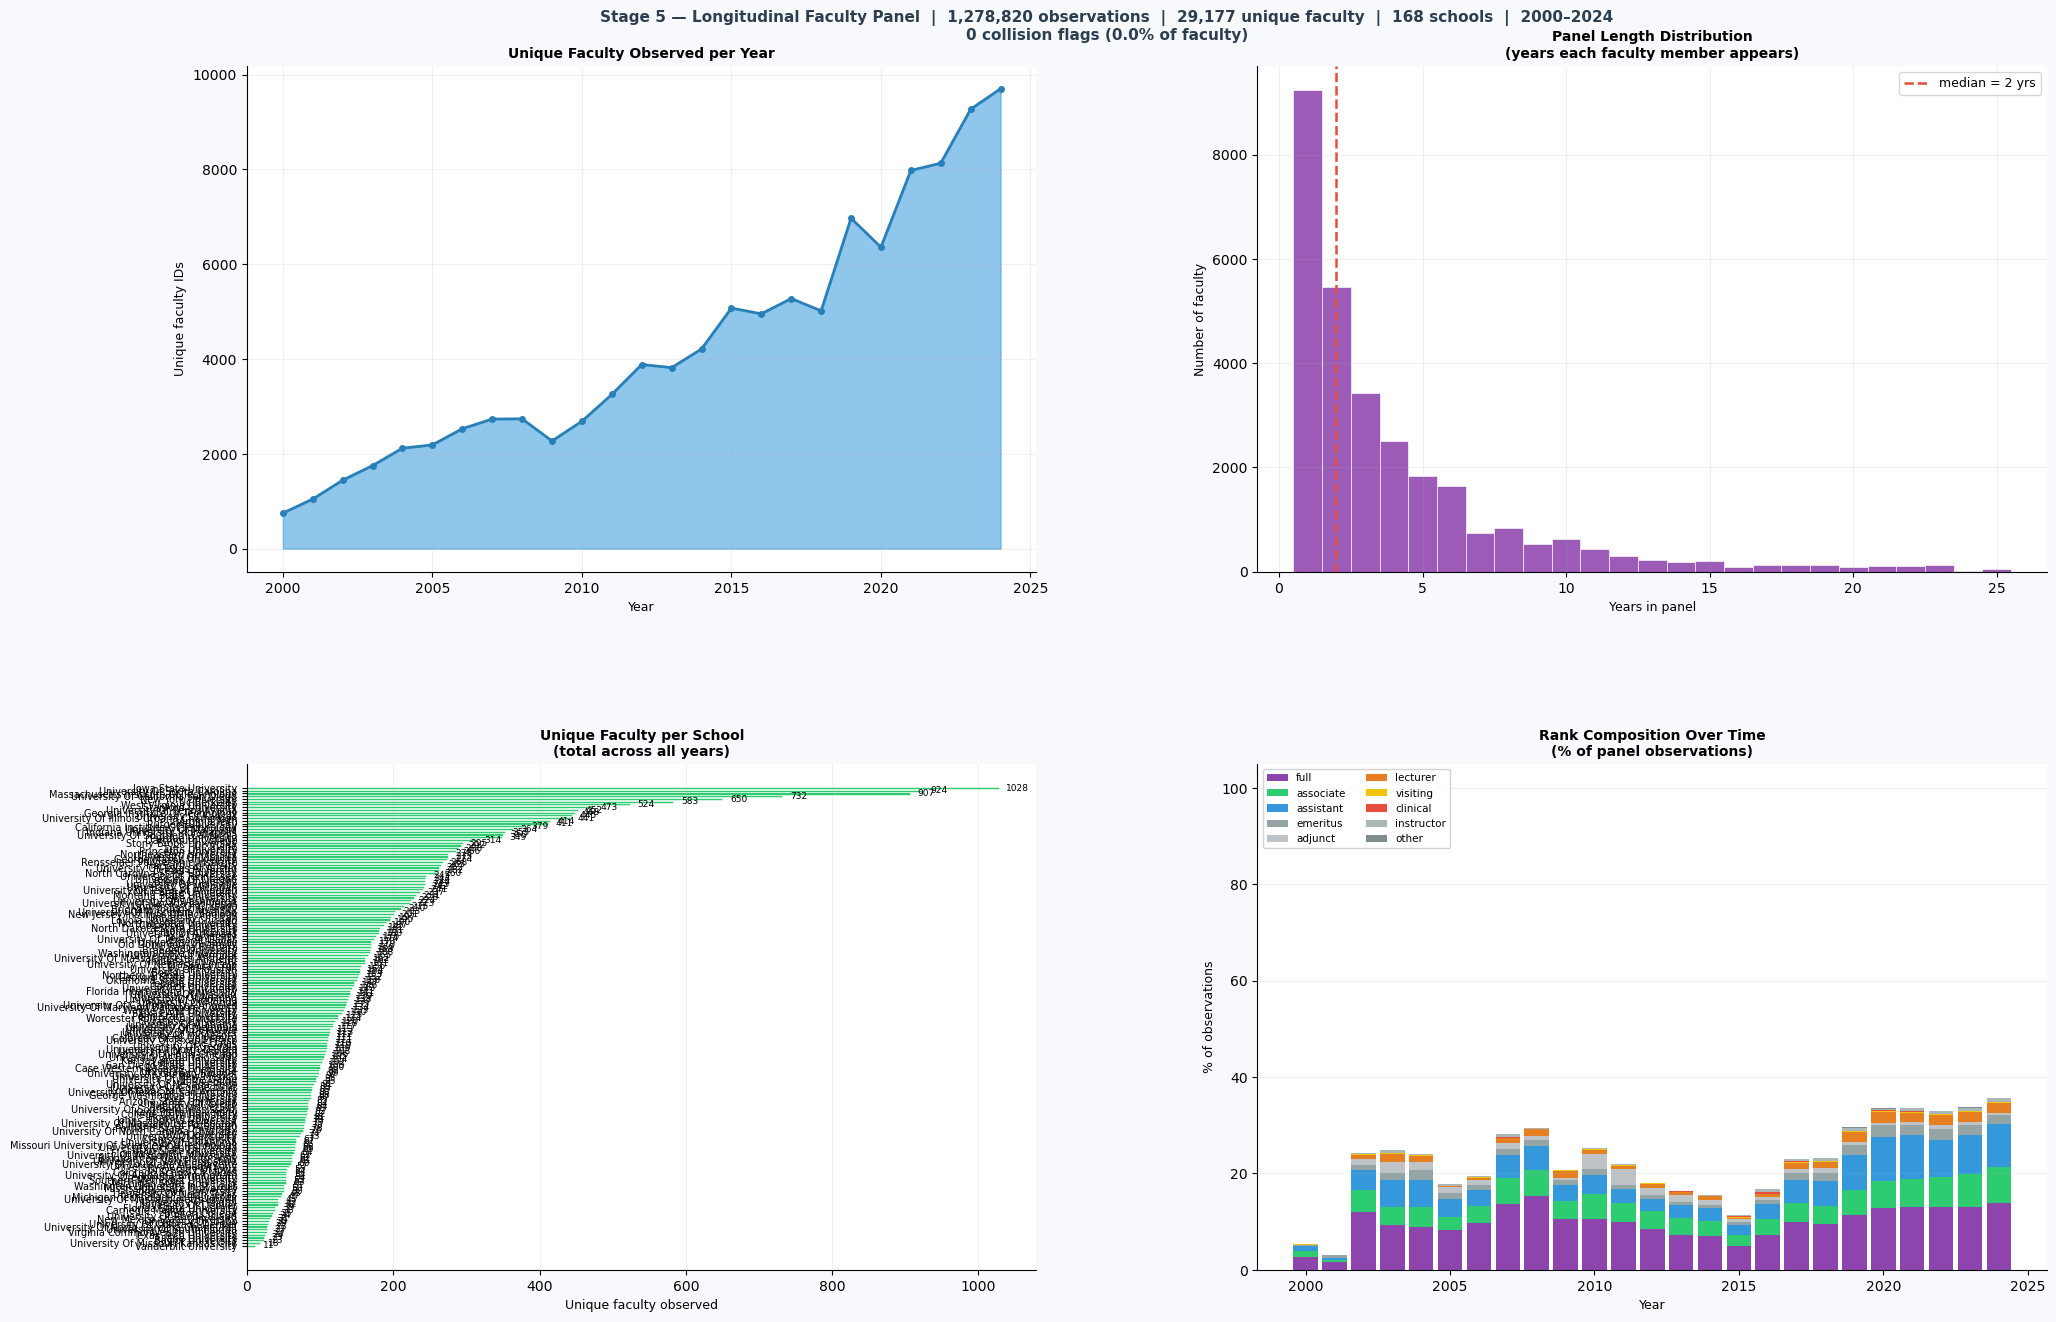


  Saved -> /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/tenure_pipeline/stage5_panel_summary.png


In [17]:
# === CELL 5-VIZ: LONGITUDINAL PANEL — SUMMARY VISUALIZATION ===
# Plotting logic lives in tenure_pipeline/viz_pipeline.py — edit there.
import json as _json
reload_py_files()
import viz_pipeline

# Load panel from disk if Cell 5 hasn't been run this session
if 'panel_records' not in dir() or not panel_records:
    with open(STAGE5_OUT, encoding='utf-8') as _f:
        panel_records = [_json.loads(l) for l in _f if l.strip()]
    print(f"  Loaded {len(panel_records):,} panel records from disk.")

VIZ_SCHOOL_SORT = 'volume'  # 'alphabetical' — A→Z on unique-faculty-per-school bar chart (panel 3)

viz_pipeline.plot_stage5(
    panel_records   = panel_records,
    df_schools      = df_schools,
    out_path        = TENURE_PIPELINE_DIR / 'stage5_panel_summary.png',
    panel_path      = STAGE5_OUT,
    collision_path  = STAGE5_COLLISIONS,
    school_sort     = VIZ_SCHOOL_SORT,
)

# 🔎 CELL 6A: Stage 6A — OpenAlex Author ID Resolution

**Two steps:**
1. Map each of the 54 school slugs to an OpenAlex institution ID (one-time, ~54 API calls).
2. For each of the 4,619 unique faculty members, search OpenAlex by name + institution and assign an OpenAlex Author ID with a confidence score (HIGH / MEDIUM / LOW / MULTI / NONE).

**Output files:**
- `openalex_inst_map.json` — school slug → OpenAlex institution record
- `openalex_author_ids.jsonl` — one record per faculty member with OpenAlex ID + confidence
- `openalex_low_confidence.jsonl` — MULTI / LOW / NONE matches for human review

**Rate limit:** uses `mailto=dzk3ja@virginia.edu` (elevated pool). Checkpointed — safe to interrupt and resume.

In [26]:
# === CELL 6A: STAGE 6A — OPENALEX AUTHOR ID RESOLUTION ===
# Resolution logic lives in tenure_pipeline/openalex_resolver.py — edit there.
import importlib, sys as _sys, json as _json
_tp = str(TENURE_PIPELINE_DIR)
if _tp not in _sys.path:
    _sys.path.insert(0, _tp)
import openalex_resolver as oar
import stage6_pilot as s6p
importlib.reload(oar)
importlib.reload(s6p)

# Load panel from disk if not in memory
if 'panel_records' not in dir() or not panel_records:
    with open(STAGE5_OUT, encoding='utf-8') as _f:
        panel_records = [_json.loads(l) for l in _f if l.strip()]
    print(f"  Loaded {len(panel_records):,} panel records from disk.")

if RUN_CELL6A:
    clk = time_start("Stage 6A — OpenAlex Author ID Resolution")

    # Pilot order: rank schools by panel faculty count (+ rows), optional Stage 4 audit sanity filter
    panel_records, uni_slugs, _s6 = s6p.prepare_stage6_panel(
        panel_records,
        STAGE4_STRAT_OUT,
        pilot_mode=STAGE6_PILOT_MODE,
        pilot_top_n=STAGE6_PILOT_TOP_N,
        sanity_filter=STAGE6_SANITY_FILTER,
        sanity_max_none_frac=STAGE6_SANITY_MAX_NONE_FRAC,
        sanity_min_audit_rows=STAGE6_SANITY_MIN_AUDIT_ROWS,
    )
    if STAGE6_PILOT_MODE:
        print(f"  Stage 6 pilot: {_s6['n_schools']} schools  |  {_s6['n_panel_rows']:,} panel rows  |  strat file: {STAGE4_STRAT_OUT.name} ({'found' if _s6['strat_found'] else 'missing'})")
        if _s6.get("n_dropped_sanity"):
            _ds = _s6["dropped_sanity"]
            _show = ", ".join(_ds[:10]) + (" …" if len(_ds) > 10 else "")
            print(f"  Dropped (audit frac_none > {STAGE6_SANITY_MAX_NONE_FRAC:.0%}): {_s6['n_dropped_sanity']} — {_show}")
        print("  Top schools (faculty / rows / audit_frac_none):")
        for _row in _s6.get("top_schools_preview", [])[:8]:
            _fn = _row.get("frac_none")
            _fn_s = f"{_fn:.2f}" if _fn is not None else "n/a"
            print(f"    {_row['uni_slug']}: faculty={_row['n_faculty']:,} rows={_row['n_rows']:,} frac_none={_fn_s}")

    # ── Step 1: institution slug → OpenAlex institution ID ───────────────────
    if STAGE6_INST_MAP.exists():
        with open(STAGE6_INST_MAP) as _f:
            inst_map = _json.load(_f)
        print(f"  Loaded institution map ({len(inst_map)} entries) from disk.")
    else:
        print(f"  Resolving {len(uni_slugs)} institutions via OpenAlex …")
        inst_map = oar.resolve_institutions(uni_slugs)
        with open(STAGE6_INST_MAP, 'w') as _f:
            _json.dump(inst_map, _f, indent=2)
        matched = sum(1 for v in inst_map.values() if v)
        print(f"  Institution map saved — {matched}/{len(uni_slugs)} resolved.")

    # ── Step 2: author name → OpenAlex Author ID ─────────────────────────────
    print(f"\n  Resolving author IDs …")
    author_records = oar.resolve_authors(
        panel_records = panel_records,
        inst_map      = inst_map,
        out_path      = STAGE6_AUTHOR_IDS,
        skip_done     = True,
    )

    # Load full set (including previously checkpointed) for summary
    with open(STAGE6_AUTHOR_IDS, encoding='utf-8') as _f:
        author_records = [_json.loads(l) for l in _f if l.strip()]

    oar.match_summary(author_records)

    # Write low-confidence QA file
    low_conf = oar.low_confidence_report(author_records)
    with open(STAGE6_LOW_CONF, 'w', encoding='utf-8') as _f:
        for r in low_conf:
            _f.write(_json.dumps(r) + '\n')
    print(f"\n  Low-confidence records : {len(low_conf):,} → {STAGE6_LOW_CONF.name}")
    time_stop(clk)

else:
    if STAGE6_AUTHOR_IDS.exists():
        with open(STAGE6_AUTHOR_IDS, encoding='utf-8') as _f:
            author_records = [_json.loads(l) for l in _f if l.strip()]
        inst_map = _json.loads(STAGE6_INST_MAP.read_text()) if STAGE6_INST_MAP.exists() else {}
        print(f"  CELL 6A skipped — loaded {len(author_records):,} author records from disk.")
        oar.match_summary(author_records)
    else:
        print(f"  CELL 6A skipped — no author IDs found; set RUN_CELL6A = True to run  {tymeout()}")

Start Stage 6A — OpenAlex Author ID Resolution at 04:30:03 (EST) Thu, 16 Apr 2026
  Stage 6 pilot: 15 schools  |  618,066 panel rows  |  strat file: faculty_snapshots_strategy_audit.jsonl (found)
  Top schools (faculty / rows / audit_frac_none):
    iowa_state_university: faculty=1,034 rows=39,102 frac_none=0.00
    university_of_south_carolina: faculty=924 rows=23,640 frac_none=0.00
    massachusetts_institute_of_technology: faculty=907 rows=91,848 frac_none=0.00
    university_of_california_san_diego: faculty=732 rows=62,212 frac_none=0.00
    new_york_university: faculty=650 rows=40,732 frac_none=0.00
    uc_berkeley: faculty=583 rows=81,252 frac_none=0.00
    west_virginia_university: faculty=524 rows=16,016 frac_none=0.00
    stanford_university: faculty=473 rows=25,160 frac_none=0.00
  Loaded institution map (54 entries) from disk.

  Resolving author IDs …

  Faculty to resolve : 8  (14,597 already done, 8,819 total)
  API delay          : 1.00s / request  │  no API key — polite

## 📥 CELL 6B: Stage 6B — OpenAlex Works by Year

For every resolved author (per `confidence_min` in the cell, default HIGH), aggregate publication counts **by calendar year**.

**Data source (automatic):** If `OPENALEX_SNAPSHOT_ROOT` (Cell 0) contains `publicationauthoraffiliation/` and `pub2year.csv.gz` — e.g. Rivanna `~/cdh/OpenAlex1125` — Cell 6B uses those **relational CSV scans** (no API). Otherwise it uses OpenAlex's `group_by=publication_year` **API** (one call per author).

**Output:** `openalex_works_by_year.jsonl` — one record per (faculty_id, year) with `n_works`.

Checkpointed — safe to interrupt and resume. LOW confidence authors excluded by default unless you set `confidence_min="LOW"`.

In [ ]:
# === CELL 6B: STAGE 6B — OPENALEX WORKS BY YEAR ===
# For each resolved author (confidence ≥ HIGH), aggregate publication counts
# by calendar year.  Logic lives in tenure_pipeline/openalex_resolver.py.
#
# ──────────────────────────────────────────────────────────────────────────────
# HOW ROUTING WORKS — READ BEFORE CHANGING ANYTHING
# ──────────────────────────────────────────────────────────────────────────────
#
# fetch_works_by_year() auto-detects the best data source in this order:
#
# Route 1 — SNAPSHOT MODE  (on Rivanna / HPC)
#   • OPENALEX_SNAPSHOT_ROOT points to a directory that contains both
#     publicationauthoraffiliation/*.csv.gz  and  pub2year.csv.gz.
#   • Does a bulk scan of the CDH OpenAlex relational CSV tables.
#   • Uses STAGE6_WORKS_CACHE (incremental): only NEW authors not yet in
#     the cache ever trigger a scan.  All cached authors are served instantly.
#   • First-time run: ~3–5 hours.  Every subsequent run: seconds.
#   • Run as a batch job:  sbatch build_openalex_cache.slurm
#     (from repo root; Slurm logs: slurm_out/slurm-oa_cache-<JOBID>.out / .err)
#
# Route 2 — CACHE-ONLY MODE  (Mac / coffee shop / no HPC connection)
#   • Snapshot root unreachable, but STAGE6_WORKS_CACHE exists on disk
#     (built on Rivanna and rsync'd here).
#   • All cached authors → output immediately, no scan needed.
#   • New authors NOT in cache:
#     - STAGE6B_API_FALLBACK = False (default): prints exact SSH + rsync
#       instructions and returns partial results.  This is the safe default.
#     - STAGE6B_API_FALLBACK = True: uses the OpenAlex API for uncached
#       authors.  Slow (~1 req/sec) and rate-limited.  API results are NOT
#       written to the cache (cache = snapshot data only).
#
# Route 3 — API-ONLY MODE  (no snapshot, no cache, api_fallback=True)
#   • Only when STAGE6B_API_FALLBACK = True and no cache file exists.
#   • One HTTP request per author.  Use only for small exploratory runs.
#
# Route 4 — BLOCKED  (no snapshot, no cache, api_fallback=False)
#   • Prints clear instructions and returns [].  Default safe behavior.
#   • Prevents accidentally falling through to slow API calls.
#
# KEY CELL 0 CONSTANTS:
#   OPENALEX_SNAPSHOT_ROOT  — path to CDH snapshot (HPC only; set via env var)
#   STAGE6_WORKS            — output: openalex_works_by_year.jsonl
#   STAGE6_WORKS_CACHE      — incremental cache: openalex_snapshot_cache.jsonl
#   STAGE6B_API_FALLBACK    — set True only to allow API fallback (default False)
# ──────────────────────────────────────────────────────────────────────────────

import importlib, sys as _sys, json as _json
_tp = str(TENURE_PIPELINE_DIR)
if _tp not in _sys.path:
    _sys.path.insert(0, _tp)
import openalex_resolver as oar
importlib.reload(oar)

# Load author records from disk if 6A hasn't run this session
if 'author_records' not in dir() or not author_records:
    with open(STAGE6_AUTHOR_IDS, encoding='utf-8') as _f:
        author_records = [_json.loads(l) for l in _f if l.strip()]
    print(f"  Loaded {len(author_records):,} author records from disk.")

if RUN_CELL6B:
    clk = time_start("Stage 6B — OpenAlex Works by Year")

    # fetch_works_by_year routes automatically based on what's available:
    #   Rivanna + snapshot accessible  → Route 1 (snapshot scan + cache)
    #   Mac + cache file exists        → Route 2 (cache-only or cache + API)
    #   Neither + api_fallback=True    → Route 3 (API only)
    #   Neither + api_fallback=False   → Route 4 (blocked, prints instructions)
    works_records = oar.fetch_works_by_year(
        author_records  = author_records,
        out_path        = STAGE6_WORKS,
        confidence_min  = "HIGH",          # "MEDIUM" or "LOW" to include lower-confidence matches
        skip_done       = True,            # skip authors already in the works file
        snapshot_root   = OPENALEX_SNAPSHOT_ROOT,   # HPC snapshot (Route 1); unreachable on Mac → Route 2
        cache_path      = STAGE6_WORKS_CACHE,        # incremental cache (Routes 1 & 2)
        api_fallback    = STAGE6B_API_FALLBACK,      # False = safe; True = allow API for uncached authors
    )

    # ── Summary ──────────────────────────────────────────────────────────────
    if STAGE6_WORKS.exists():
        with open(STAGE6_WORKS, encoding='utf-8') as _f:
            works_records = [_json.loads(l) for l in _f if l.strip()]
        if works_records:
            n_authors = len({r['faculty_id'] for r in works_records})
            yr_min    = min(r['year'] for r in works_records)
            yr_max    = max(r['year'] for r in works_records)
            print(f"\n  Works records      : {len(works_records):,}")
            print(f"  Authors covered    : {n_authors:,}")
            print(f"  Year range         : {yr_min}–{yr_max}")
            print(f"  Output             : {STAGE6_WORKS.resolve()}")
            if STAGE6_WORKS_CACHE.exists():
                import os as _os
                cache_mb = _os.path.getsize(STAGE6_WORKS_CACHE) / 1e6
                print(f"  Cache size         : {cache_mb:.1f} MB  ({STAGE6_WORKS_CACHE.name})")
        else:
            print(f"\n  {STAGE6_WORKS.name} exists but has no rows yet.")
    else:
        print(f"\n  No {STAGE6_WORKS.name} on disk — see fetch_works_by_year messages above.")
    time_stop(clk)

else:
    # RUN_CELL6B = False — just load whatever is on disk for downstream cells
    if STAGE6_WORKS.exists():
        with open(STAGE6_WORKS, encoding='utf-8') as _f:
            works_records = [_json.loads(l) for l in _f if l.strip()]
        n_authors = len({r['faculty_id'] for r in works_records})
        print(f"  CELL 6B skipped — loaded {len(works_records):,} works records "
              f"for {n_authors:,} authors  {tymeout()}")
    else:
        print(f"  CELL 6B skipped — no works file on disk.")
        print(f"  To build: set RUN_CELL6B=True in CELL 0, re-run CELL 0, then run this cell.")
        print(f"  On Rivanna: sbatch build_openalex_cache.slurm  (logs in slurm_out/)  {tymeout()}")

Start Stage 6B — OpenAlex Works by Year at 04:30:25 (EST) Thu, 16 Apr 2026

  Authors to aggregate : 8  (2,657 OpenAlex IDs already in openalex_works_by_year.jsonl)
  Eligible (≥HIGH) w/ ID : 2,722  (from 14,605 author rows)
  Data source          : bulk snapshot (relational CSVs, no HTTP)
  ────────────────────────────────────────────────────────────
  Scanning 1,006 publicationauthoraffiliation shards …


  PAA shards:   0%|          | 0/1006 [00:00<?, ?file/s]

# 🏗️ CELL 7: Stage 7 — Enriched Annual Panel

Collapses the multi-capture Cell 5 panel to **one row per (faculty_id × year)**, joins OpenAlex publication counts (Cell 6B), and derives career events.

**What it builds** (`faculty_panel_enriched.jsonl`):

| Column | Description |
|--------|-------------|
| `rank` | Best rank observed that year across all snapshots |
| `n_snapshots` | How many panel rows contributed to this year |
| `pubs_year` | OpenAlex publications that year (0 if no match) |
| `pubs_cumulative` | Running pub total from first observed year |
| `years_as_asst_so_far` | Years observed as assistant up to this year (non-null only when `rank == assistant`) |
| `ever_assistant` | Person ever observed as assistant professor |
| `tenure_event` | Became associate/full within `STAGE7_GAP_TOLERANCE` years of last assistant obs |
| `attrition` | Last assistant year was before data ends — no promotion observed |
| `censored` | Still assistant near end of data window (right-censored) |

**Sample-loss accounting** is printed at the end — advisor requirement.

**Data source (automatic):** `STAGE5_OUT` (panel) + `STAGE6_WORKS` (pub counts) + `STAGE6_AUTHOR_IDS` (OA IDs + confidence).

In [5]:
# === CELL 7: STAGE 7 — ENRICHED ANNUAL PANEL ===
# Panel-building logic lives in tenure_pipeline/panel_builder.py
import importlib, panel_builder as pb
importlib.reload(pb)

if RUN_CELL7:
    clk = time_start("Stage 7 — Enriched Annual Panel")

    panel7_loss = pb.build_annual_panel(
        panel_path    = STAGE5_OUT,
        works_path    = STAGE6_WORKS,
        author_path   = STAGE6_AUTHOR_IDS,
        out_path      = STAGE7_OUT,
        min_year      = CDX_YEAR_MIN,
        max_year      = CDX_YEAR_MAX,
        gap_tolerance = STAGE7_GAP_TOLERANCE,
    )

    time_stop(clk)
    print(f"\n  Output → {STAGE7_OUT}")

else:
    # Load existing enriched panel from disk so downstream cells have data in memory.
    if STAGE7_OUT.exists():
        import pandas as _pd7
        panel7_df = _pd7.read_json(STAGE7_OUT, lines=True)
        panel7_loss = {"output_rows": len(panel7_df), "note": "loaded from disk (RUN_CELL7=False)"}
        print(f"  CELL 7 skipped — loaded {len(panel7_df):,} rows from {STAGE7_OUT.name}  {tymeout()}")
        del _pd7
    else:
        panel7_loss = {}
        print(f"  CELL 7 skipped — no enriched panel on disk; set RUN_CELL7=True in CELL 0, re-run CELL 0, then run this cell.  {tymeout()}")

Start Stage 7 — Enriched Annual Panel at 16:01:58 (EST) Fri, 17 Apr 2026
  Loading OpenAlex author IDs …
    15,519 author-ID records loaded
  Loading OpenAlex works …
    116,817 works rows for 2,902 faculty_ids
  Loading faculty panel …
    2,560,018 panel rows  →  29,274 unique faculty_ids
  Collapsing to annual observations …
  Deriving career events …
  Writing enriched panel …

  ────────────────────────────────────────────────────────────
  Stage 7 complete in 16.6s
  Output rows          : 106,559
  Unique faculty_ids   : 29,274
  ├─ ever assistant    : 2,331  (8.0%)
  │   ├─ tenure event  : 384  (16.5% of asst)
  │   ├─ attrition     : 738  (31.7% of asst)
  │   └─ censored      : 1,209  (51.9% of asst)
  Faculty w/ OA works  : 2,799  (9.6% of all)
  Asst. faculty w/ OA  : 403  (17.3% of asst)
  ────────────────────────────────────────────────────────────
  ⚠  NOTE: 1,928 assistant faculty have no OA publication data.
     Peer-pool models using pubs will be restricted to the 

# 📐 CELL 8: Stage 8 — LOO Peer Pool Metrics

For each assistant professor in each department-year, computes **leave-self-out (LOO) peer quality** — the mean publication rate of all *other* OA-matched assistant professors in the same department and year.

This is the **core independent variable** for the inverted-U test, mirroring:
- **Army:** LOO mean OER score in the senior-rater cohort
- **Basketball:** LOO mean points-per-minute among teammates

| Column added | Description |
|---|---|
| `pool_size_all` | Total assistant profs in dept-year (all, incl. no OA data) |
| `pool_size_oa` | Assistant profs with OA publication data in dept-year |
| `pool_size_oa_loo` | OA pool after excluding person i |
| `poolq_loo_mean` | LOO mean pubs — **the peer quality measure** (`None` if no OA peers) |
| `poolq_loo_sd` | LOO std dev pubs |
| `pool_rank_loo` | Person i's rank in the full OA pool (1 = lowest) |
| `pool_pctile_loo` | Percentile in OA pool (0–100) |

**Coverage note:** Only ~17% of assistant faculty have OpenAlex data. LOO will be `None` for dept-years with no OA-matched peers. The inverted-U analysis uses the computable subset — this is reported explicitly.

In [6]:
# === CELL 8: STAGE 8 — LOO PEER POOL METRICS ===
# Pool metric logic lives in tenure_pipeline/pool_metrics.py
import importlib, pool_metrics as pm
importlib.reload(pm)

if RUN_CELL8:
    clk = time_start("Stage 8 — LOO Peer Pool Metrics")

    panel8_summary = pm.build_pool_metrics(
        in_path  = STAGE7_OUT,
        out_path = STAGE8_OUT,
    )

    time_stop(clk)
    print(f"\n  Output → {STAGE8_OUT}")

else:
    if STAGE8_OUT.exists():
        import pandas as _pd8
        panel8_df = _pd8.read_json(STAGE8_OUT, lines=True)
        panel8_summary = {"output_rows": len(panel8_df), "note": "loaded from disk (RUN_CELL8=False)"}
        print(f"  CELL 8 skipped — loaded {len(panel8_df):,} rows from {STAGE8_OUT.name}  {tymeout()}")
        del _pd8
    else:
        panel8_summary = {}
        print(f"  CELL 8 skipped — no pool panel on disk; set RUN_CELL8=True in CELL 0, re-run CELL 0, then run this cell.  {tymeout()}")

Start Stage 8 — LOO Peer Pool Metrics at 16:02:38 (EST) Fri, 17 Apr 2026
  Pass 1: building dept-year pools …
    106,559 input rows
    621 dept-years with pool-rank faculty
    ├─ dept-years with ≥1 OA member : 265
    ├─ dept-years with ≥2 OA members: 242  (LOO computable)
    └─ dept-years with 0 OA members : 356  (LOO = None)
  Pass 2: writing augmented panel …

  ────────────────────────────────────────────────────────────
  Stage 8 complete in 2.0s
  Output rows              : 106,559
  Asst rows w/ LOO computable : 3,220
  Asst rows w/ LOO = None     : 3,417  (no OA peers after LOO)
  Asst rows w/ rank computable: 2,604
  ────────────────────────────────────────────────────────────
  ⚠  LOO is None for ~51% of assistant rows — OA coverage gap.
     Inverted-U analysis will use the 3,220-row subset with computable LOO.
  ────────────────────────────────────────────────────────────
...complete. duration: 01.96 seconds at 16:02:40 (EST) Fri, 17 Apr 2026

  Output → /sfs/gpfs/tardi

# 📈 CELL 9: Stage 9 — Inverted-U Analysis

First end-to-end empirical check of the inverted-U hypothesis.

**Population:** 1,017 assistant faculty with at least one computable LOO peer quality value.
Each person is summarised by their **mean LOO** (mean pubs/yr of co-hired assistant-rank peers, leave-self-out) across all assistant years with valid LOO data.

**Outcome rates** are computed on *resolved* cases only (tenure + attrition).
Censored faculty (still appearing as assistant ~2024) are counted but excluded from rate denominators.

| Output | Description |
|--------|-------------|
| `stage9_inverted_u.png` | 2-panel plot: tenure rate and attrition rate by LOO decile (95% Wilson CI) |
| `stage9_binned_table.csv` | Full per-bin summary (N, rates, CIs, LOO range) |


Start Stage 9 — Inverted-U Analysis at 16:11:11 (EST) Fri, 17 Apr 2026
  Loading person-level data …

  ── Sample-loss accounting ──────────────────────────────────
  Persons with computable LOO (analysis population) : 1,104
    → tenure events      : 197  (17.8%)
    → attrition          : 380  (34.4%)
    → censored (still asst ≈ 2024) : 527  (47.7%)
  Resolved (tenure + attrition)    : 577  ← N for rate calcs
  bin_method='quantile'  log_bin=False  z_score=True  exclude_censored=True
  Note: log_bin/z_score have no effect on quantile bin assignment (rank-preserving); transformed values shown in table/plot for reference.

  ── Binned rates (18 quantile bins) ────────────────────────────────
  Bin   N_all   N_res    Ten%    Att%   LOO_med    LOO_z  N_cens
  --------------------------------------------------------------
    1      62      52   15.4%   84.6%      0.27    -1.14      10
    2      61      28   14.3%   85.7%      0.62    -1.06      33
    3      61      37   45.9%   54.1% 

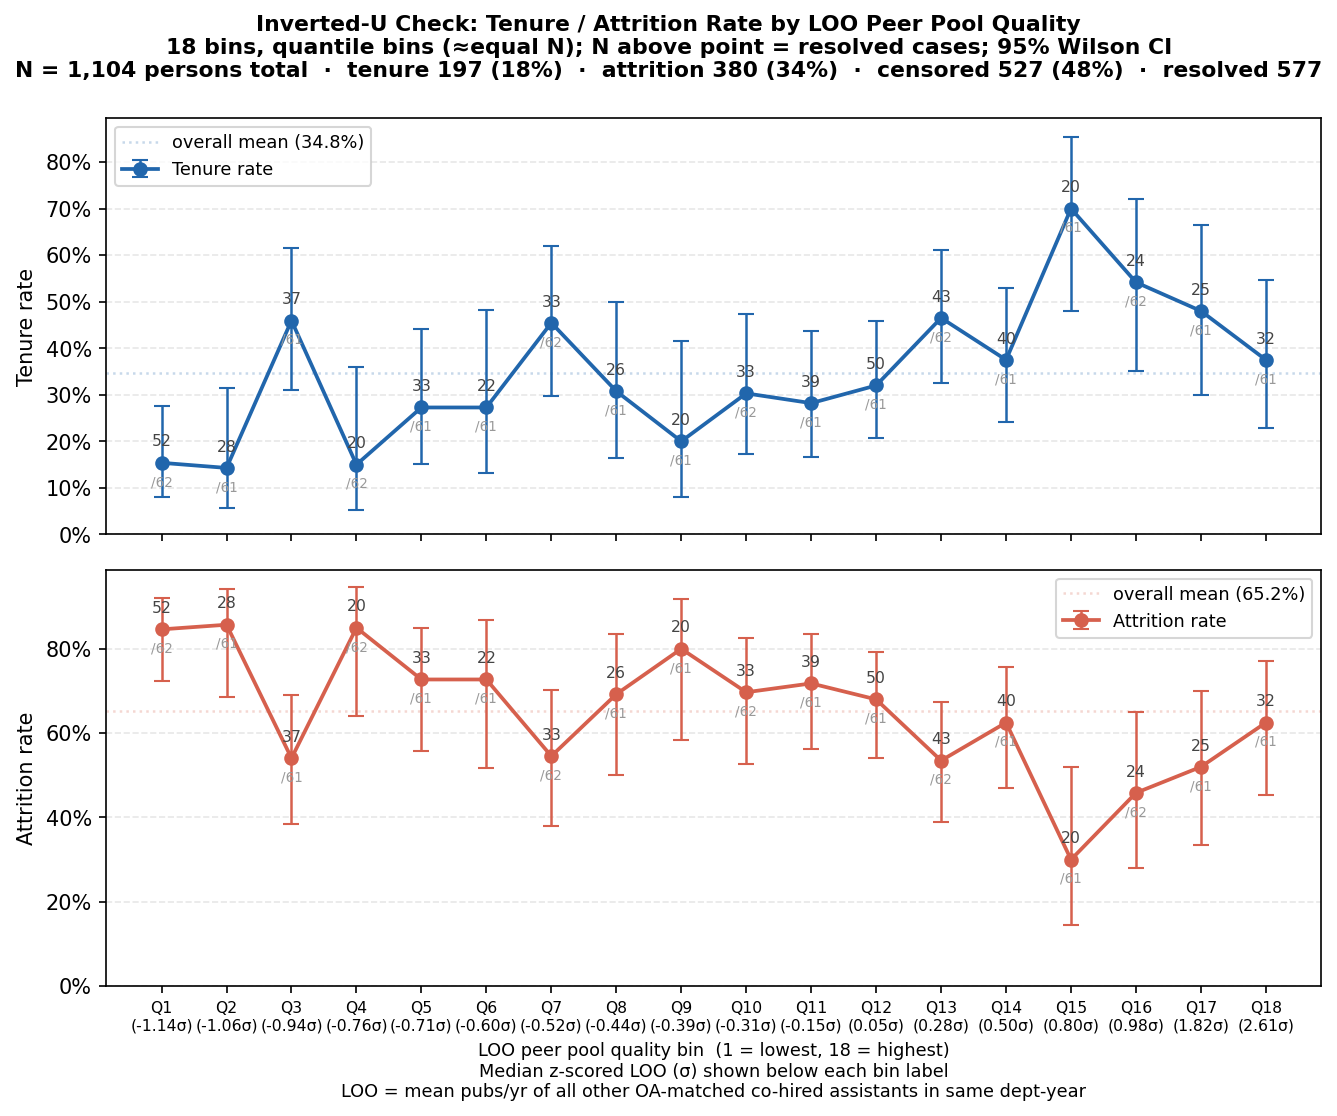

In [18]:
# === CELL 9: STAGE 9 — INVERTED-U ANALYSIS ===
# Analysis logic lives in tenure_pipeline/stage9_analysis.py
import importlib, stage9_analysis as s9
importlib.reload(s9)

if RUN_CELL9:
    clk = time_start("Stage 9 — Inverted-U Analysis")
    panel9_summary = s9.build_inverted_u(
        in_path         = STAGE8_OUT,
        out_dir         = TENURE_PIPELINE_DIR,
        n_bins          = STAGE9_N_BINS,
        exclude_censored= True,
        bin_method      = STAGE9_BIN_METHOD,
        z_score         = STAGE9_Z_SCORE,
    )
    time_stop(clk)
    print(f"\n  PNG   → {STAGE9_FIG}")
    print(f"  Table → {STAGE9_TABLE}")

    # Display the plot inline
    from IPython.display import Image, display
    display(Image(filename=str(STAGE9_FIG)))
else:
    if STAGE9_FIG.exists():
        from IPython.display import Image, display
        display(Image(filename=str(STAGE9_FIG)))
        print(f"  CELL 9 skipped — showing saved plot from {STAGE9_FIG.name}  {tymeout()}")
    else:
        print(f"  CELL 9 skipped — no plot on disk; set RUN_CELL9=True in CELL 0, re-run CELL 0, then run this cell.  {tymeout()}")
